In [1]:
import time

start_time = time.time()
print(f"Start time recorded: {start_time}")

Start time recorded: 1767074697.595005


<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/phonchi/CryoParticleSegment/blob/main/notebook/02_finetune_with_crf_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

### CryoParticleSegment

In [2]:
# @markdown package install
do = False # @param{type:"boolean"}
if do:
    %pip install torchinfo -qq
    %pip install -U git+https://github.com/qubvel/segmentation_models.pytorch -qq

## ⭐ Setup
You must run all codes under this category.

In [3]:
if do:
    !git clone https://github.com/phonchi/CryoParticleSegment.git

    !wget -O /content/CryoParticleSegment/Modeling/convcrf.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/convcrf.py
    !wget -O /content/CryoParticleSegment/Modeling/dataset.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/dataset.py
    !wget -O /content/CryoParticleSegment/Modeling/model.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/model.py
    # !wget -O /content/CryoParticleSegment/Modeling/trainer.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/trainer.py

    !wget -O /content/CryoParticleSegment/Modeling/trainer.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/weight_view_02/trainer.py

In [4]:
import sys
import os

# Adjust the path relative to your current working directory
module_path = os.path.abspath('CryoParticleSegment/Modeling')

# Add to sys.path if it's not already included
if module_path not in sys.path:
    sys.path.append(module_path)

> #### ⚠ Notice
>
> You need to restart the kernel after the compilation step. Additionally, if your GPU architecture differs, you may need to modify the file at `/content/CryoParticleSegment/Modeling/CRF_main/setup.py`. (We attempt to detect the GPU configuration automatically, so this step is usually not necessary.)
> Furthermore, depending on the number of classes and other parameters, you may encounter an error that requires adjusting the file at `/content/CryoParticleSegment/Modeling/CRF_main/src/PermutohedralFiltering/source/gpu/LatticeFilter.cu`:
>
> 1. Note the `pd` and `vd` values from the error message.
> 2. Add an `else if (pd == ? && vd == ?)` block.
> 3. Within that block, insert the following line, replacing `pd` and `vd` with the specific values:
>
>    ```cpp
>    latticeFilterGPU<pd, vd>(output_tensor, input_tensor, positions, num_super_pixels, backward);
>    ```
> 4. Recompile using `setup.py`.

In [5]:
if do:
    #!git clone https://github.com/netw0rkf10w/CRF.git
    %cd CryoParticleSegment/Modeling/CRF_main
    !python setup.py clean --all
    !rm -rf build/
    !python setup.py build_ext --inplace --force
    !python setup.py install

    crf_path = os.path.join(os.getcwd(), 'CRF')
    if crf_path not in sys.path:
        sys.path.insert(0, crf_path)

    print(f"Added {crf_path} to the Python path.")

In [6]:
%cd /content/

/content


### ✅ Directory Settings

In [7]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [8]:
# @title  { display-mode: "form" }

INPUT_IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
IMAGE_DIR = INPUT_IMAGE_DIR
# @markdown ---

use_denoised_as_pariwise = False # @param {type : "boolean"}
dnzd_pw = use_denoised_as_pariwise
DENOISED_IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
# @markdown ---

LABEL_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output/dataset/10017/micrographs_ground_np" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF" # @param {type:"string"}

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
!cp -r {DENOISED_IMAGE_DIR} /content/denoised_image_dir
DENOISED_IMAGE_DIR = "/content/denoised_image_dir"

In [11]:
# @title  { display-mode: "form" }
# @markdown Detect whether using folder in Google Drive as **`RESULT DIR`**📁.
import os
if "content" in IMAGE_DIR.split("/")[:3] or "content" in LABEL_DIR.split("/")[:3]:
  try:
    from google.colab import drive
    drive.mount('/content/drive')
    !rm -r /content/sample_data
    if not os.path.exists("/content/image_dir"):
        if "content" in IMAGE_DIR.split("/")[:3]:
            !cp -r {IMAGE_DIR} /content/image_dir
            IMAGE_DIR = "/content/image_dir"
        if "content" in LABEL_DIR.split("/")[:3]:
            !cp -r {LABEL_DIR} /content/label_dir
            LABEL_DIR = "/content/label_dir"
        if dnzd_pw == True:
            !cp -r {DENOISED_IMAGE_DIR} /content/denoised_image_dir
            DENOISED_IMAGE_DIR = "/content/denoised_image_dir"
  except:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### ✅ Packages Handling

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, OneCycleLR

In [13]:
from dataset import MicrographDataset, MicrographDatasetEvery
from dataset import reconstruct_patched, collate_fn
from model import create_model
from trainer import CryoEMEvaluator
from trainer import CryoEMTrainerWithScheduler, tqdm_plugin_for_Trainer

## ⭐ Main

### ✅ Setting

In [14]:
# @markdown Parameters.

user = True # @param {type:"boolean"}

In [15]:
# @markdown Parameters.

NUM_CLASSES = 2
EPOCHS = 100
BATCH = 2
CROP_SIZE = (512, 512)
LR = 1e-3

RLR_PATIENCE = 3
ES_PATIENCE = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [16]:
# @markdown Set seed.

random_state = 42
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)

### ✅ Dataset

You can provide a [`transforms.CenterCrop(3840)`](https://docs.pytorch.org/vision/master/generated/torchvision.transforms.CenterCrop.html) object to crop out boundary artifacts.


In [17]:
crop = transforms.CenterCrop(3840)

In [18]:
train_dir = os.path.join(IMAGE_DIR, 'train')
train_filenames = np.loadtxt(f"{IMAGE_DIR}/train_filenames.txt", dtype=str)
if dnzd_pw == False:
    train_dataset = MicrographDataset(image_dir=train_dir, label_dir=LABEL_DIR, filenames=train_filenames, crop_size=CROP_SIZE, num_patches = 4, crop=crop)
else:
    dnzd_train_dir = os.path.join(DENOISED_IMAGE_DIR, 'train')
    train_dataset = MicrographDataset(image_dir=train_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_train_dir, filenames=train_filenames, crop_size=CROP_SIZE, num_patches = 4, crop=crop)

In [19]:
val_dir = os.path.join(IMAGE_DIR, 'val')
val_filenames = np.loadtxt(f"{IMAGE_DIR}/val_filenames.txt", dtype=str)
if dnzd_pw == False:
    val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=LABEL_DIR, filenames=val_filenames, crop_size=CROP_SIZE, crop=crop)
else:
    dnzd_val_dir = os.path.join(DENOISED_IMAGE_DIR, 'val')
    val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_val_dir, filenames=val_filenames, crop_size=CROP_SIZE, crop=crop)
val_loader = DataLoader(val_dataset, batch_size=None, shuffle=False, pin_memory=True, collate_fn=collate_fn)

In [20]:
if not user:
    test_dir = os.path.join(IMAGE_DIR, 'test')
    test_filenames = np.loadtxt(f"{IMAGE_DIR}/test_filenames.txt", dtype=str)
    if dnzd_pw == False:
        test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, filenames=test_filenames, crop_size=CROP_SIZE)
    else:
        dnzd_test_dir = os.path.join(DENOISED_IMAGE_DIR, 'test')
        test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_test_dir, filenames=test_filenames, crop_size=CROP_SIZE)

    test_loader = DataLoader(test_dataset, batch_size=None, shuffle=False, pin_memory=True, collate_fn=collate_fn)

In [21]:
for i1, i2, i3, i4, i5 in val_loader: #test loader and reconstruct
    print(i3.dtype, i5.dtype)
    print(i3.shape, i5.shape)
    break

torch.int64 torch.int64
torch.Size([81, 1, 512, 512]) torch.Size([1, 3840, 3840])


## ⭐ Convcrf wtih FCN finetuned on cryoem

## The model

### ✅ Model

Currently, we only test `fw` and `mf` solver as described in the paper. You could set `use_unary_only` to `True` to obtained CD-CRF, while setting `False` return to traditional CRF.

In [22]:
# @title  { display-mode: "form" }

architecture = "Unet++" # @param {type:"string"}
encoder = "timm-efficientnet-b5" # @param {type:"string"}
pretrained = True # @param {type:"boolean"}
solver = "fw" # @param {type:"string"}
use_unary_only = False # @param {type:"boolean"}
loss = "dice" # @param {type:"string"}

In [23]:
import segmentation_models_pytorch as smp

if pretrained:
  weights = "imagenet"
else:
  weights = None

if architecture == "Unet++":
    backbone = smp.UnetPlusPlus(
        encoder_name=encoder,        # choose encoder, densenet201, resnet50, e.g. mobilenet_v2 or efficientnet-b5
        encoder_weights=weights,     # use `imagenet` or `advprop` for pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=2,                      # model output channels (number of classes in your dataset)
    )

elif architecture == "Deeplab":
    backbone = smp.DeepLabV3(
        encoder_name=encoder,        # choose encoder, densenet201, resnet50, e.g. mobilenet_v2 or efficientnet-b5
        encoder_weights=weights,     # use `imagenet` pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=2,                      # model output channels (number of classes in your dataset)
    )
else:
    print("Architecture not supported")
    raise NotImplementedError

model = create_model(backbone, addout=True) #crf_args

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

In [24]:
# @markdown input the dir_name where you store the model in best notebook  01
dir_name = "unet_eb5_dice" # @param {type:"string"}
CHECKPOINT_PATH = os.path.dirname(RESULT_DIR.rstrip(os.path.sep)) + f"/{dir_name}"

dir_path = CHECKPOINT_PATH
import glob
search_pattern = os.path.join(dir_path, '*.pt')
list_of_files = glob.glob(search_pattern)
latest_file = max(list_of_files, key=os.path.getmtime)
print(f"Directory searched: {dir_path}")
print("-" * 30)
print(f"The **last modified checkpoint** file is:\n{latest_file}")


state_dict_path = latest_file
state_dict = torch.load(state_dict_path, map_location=torch.device(DEVICE))
model.load_state_dict(state_dict, strict=False)
model.to(DEVICE)
model.eval()
print("Load model at: ", state_dict_path)

Directory searched: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice
------------------------------
The **last modified checkpoint** file is:
/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice/checkpoint48.pt
Load model at:  /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice/checkpoint48.pt


In [25]:
import CRF
import torch.nn as nn
from model import setup_crf, create_fwcrf_model

# Example usage
solver = 'fw'  # Assuming the solver type is defined

crf = setup_crf(solver, NUM_CLASSES)
model_post = create_fwcrf_model(model.backbone, crf, use_unary_only=use_unary_only)

CRF solver: fw
x0_weight: 0.0
FrankWolfeParams: 
	 scheme:	 fixed 
	 stepsize:	 1.0 (for the 'fixed' scheme) 
	 regularizer:	 l2
	 lambda_:	 1.0
	 lambda_learnable:	 False
	 x0_weight:	 0.5
	 x0_weight_learnable:	 False
Non-trainable lambda for Frank-Wolfe: 1.0
Non-trainable x0_weight for Frank-Wolfe: 0.5
Potts: remove random weights.
Add 1.0 to spatial_weight diagonal
Add 1.0 to bilateral_weight diagonal
Add -1.0 to compatibility diagonal


In [26]:
params = [
    {'params': model.backbone.parameters(), 'lr': 1e-5},  # Lower learning rate for fine-tuning the backbone
    {'params': crf.parameters(), 'lr': 1e-3}         # Higher learning rate for training the CRF from scratch
]

In [27]:
print(model_post)

ModelWithFWCRF(
  (backbone): UnetPlusPlus(
    (encoder): EfficientNetEncoder(
      (conv_stem): Conv2d(1, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNormAct2d(
        48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): Swish()
      )
      (blocks): Sequential(
        (0): Sequential(
          (0): DepthwiseSeparableConv(
            (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
            (bn1): BatchNormAct2d(
              48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): Swish()
            )
            (aa): Identity()
            (se): SqueezeExcite(
              (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
              (act1): Swish()
              (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
              (g

In [28]:
from torchinfo import summary
summary(model_post, input_size=(BATCH, 1, 512, 512))

Layer (type:depth-idx)                                  Output Shape              Param #
ModelWithFWCRF                                          [2, 2, 512, 512]          --
├─UnetPlusPlus: 1-1                                     [2, 2, 512, 512]          --
│    └─EfficientNetEncoder: 2-1                         [2, 1, 512, 512]          1,052,672
│    │    └─Conv2d: 3-1                                 [2, 48, 256, 256]         432
│    │    └─BatchNormAct2d: 3-2                         [2, 48, 256, 256]         96
│    │    └─Sequential: 3-3                             --                        27,286,720
│    └─UnetPlusPlusDecoder: 2-2                         [2, 16, 512, 512]         --
│    │    └─ModuleDict: 3-4                             --                        3,569,152
│    └─SegmentationHead: 2-3                            [2, 2, 512, 512]          --
│    │    └─Conv2d: 3-5                                 [2, 2, 512, 512]          290
│    │    └─Identity: 3-6           

In [29]:
import math
if loss == "dice":
    criterion = smp.losses.DiceLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
elif loss == "cross_entropy":
    criterion = smp.losses.SoftCrossEntropyLoss(smooth_factor=0.1)
elif loss == "jaccard":
    criterion = smp.losses.JaccardLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
elif loss == "Lovasz":
    criterion = smp.losses.LovaszLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
elif loss == "Tversky":
    criterion = smp.losses.TverskyLoss(smp.losses.MULTICLASS_MODE, from_logits=True, alpha=0.7, beta=0.3, gamma=1, smooth=0.1)
else:
    print("Loss not supported")
    raise NotImplementedError
optimizer = torch.optim.Adam(params)
#scheduler = ReduceLROnPlateau(optimizer, patience=RLR_PATIENCE, verbose=True)
#scheduler = OneCycleLR(optimizer, max_lr=LR, verbose=True, steps_per_epoch=math.ceil(len(train_dataset)/BATCH), epochs=EPOCHS)

In [30]:
!mkdir -p {RESULT_DIR}

In [31]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

### ✅ Training

In [32]:
# Unet++ eb5 CDCRF fw
Trainer = tqdm_plugin_for_Trainer(CryoEMTrainerWithScheduler)
trainer = Trainer(model_post, train_dataset, criterion, optimizer, DEVICE,
              num_classes = NUM_CLASSES, patience=ES_PATIENCE)

trainer.train(EPOCHS, val_loader=val_loader, batch_size = BATCH,
              ckpt_dir = RESULT_DIR, random_state = random_state)

Epoch   1/100:


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1437
Epoch 1: W2(Smoothness) Diag_Mean -> 1.000046
Epoch 1: W2(Smoothness) Off_Diag_Mean -> -0.000050
tensor([[ 9.9980e-01, -2.9453e-04],
        [ 1.9476e-04,  1.0003e+00]])
Epoch 1: W1(Appearance) Diag_Mean -> 0.999944
Epoch 1: W1(Appearance) Off_Diag_Mean -> 0.000052
tensor([[ 9.9972e-01, -1.6855e-04],
        [ 2.7324e-04,  1.0002e+00]])


Validation:   0%|          | 0/6 [00:00<?, ?it/s]

Validation score:
  loss : 0.1572
Iou by Class: [0.87253106 0.6301927 ]
Precision by Class: [0.94426125 0.74090016]
Recall by Class: [0.9199107  0.80833775]
Accuracy by Class: [0.89527875 0.89527875]
F1_score by Class: [0.93192697 0.77315116]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint1.pt
Loss improve to 0.15719838440418243.
Epoch   2/100:


...

Validation score:
  loss : 0.1536
Iou by Class: [0.87441236 0.6383342 ]
Precision by Class: [0.9479156  0.74083745]
Recall by Class: [0.9185444  0.82185906]
Accuracy by Class: [0.8971993 0.8971993]
F1_score by Class: [0.932999  0.7792479]
No improvement for 3 epoch.
Epoch 100/100:


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1463
Epoch 100: W2(Smoothness) Diag_Mean -> 1.011723
Epoch 100: W2(Smoothness) Off_Diag_Mean -> -0.011727
tensor([[ 0.9965, -0.0268],
        [ 0.0034,  1.0270]])
Epoch 100: W1(Appearance) Diag_Mean -> 1.001371
Epoch 100: W1(Appearance) Off_Diag_Mean -> -0.001328
tensor([[ 0.9859, -0.0167],
        [ 0.0141,  1.0169]])


Validation:   0%|          | 0/6 [00:00<?, ?it/s]

Validation score:
  loss : 0.1533
Iou by Class: [0.87565035 0.6380666 ]
Precision by Class: [0.9460388 0.7466035]
Recall by Class: [0.9216851 0.8144414]
Accuracy by Class: [0.8980089 0.8980089]
F1_score by Class: [0.93370324 0.7790484 ]
No improvement for 4 epoch.


In [47]:
# @title function weight plot
import re
import matplotlib.pyplot as plt
import pandas as pd

def plot_weight_curves(lines):

    epochs = []
    w1_00 = []
    w1_11 = []
    w2_00 = []
    w2_11 = []

    lines = lines.split('\n')
    current_epoch = None
    expect_w2 = False
    expect_w1 = False
    w2_data = []
    w1_data = []

    i = 0
    while i < len(lines):
        line = lines[i]

        # Check for Epoch header
        epoch_match = re.search(r'Epoch\s+(\d+)/100:', line)
        if epoch_match:
            current_epoch = int(epoch_match.group(1))

        # Check for W2 line
        if 'W2(Smoothness) Off_Diag_Mean' in line:
            expect_w2 = True
            i += 1
            continue

        # Check for W1 line
        if 'W1(Appearance) Off_Diag_Mean' in line:
            expect_w1 = True
            i += 1
            continue

        if expect_w2:
            if line.startswith('tensor'):
                # This line and next line contain the tensor
                # Line format: tensor([[ A, B],
                row1 = line
                row2 = lines[i+1]

                # Extract numbers
                nums1 = re.findall(r'[-+]?\d*\.\d+(?:[eE][-+]?\d+)?', row1)
                nums2 = re.findall(r'[-+]?\d*\.\d+(?:[eE][-+]?\d+)?', row2)

                if len(nums1) >= 1 and len(nums2) >= 2:
                    w2_00_val = float(nums1[0])
                    w2_11_val = float(nums2[1]) # The second number in second row is 1,1
                    w2_data.append((current_epoch, w2_00_val, w2_11_val))

                expect_w2 = False
                i += 1 # Skip next line
                continue

        if expect_w1:
            if line.startswith('tensor'):
                row1 = line
                row2 = lines[i+1]

                nums1 = re.findall(r'[-+]?\d*\.\d+(?:[eE][-+]?\d+)?', row1)
                nums2 = re.findall(r'[-+]?\d*\.\d+(?:[eE][-+]?\d+)?', row2)

                if len(nums1) >= 1 and len(nums2) >= 2:
                    w1_00_val = float(nums1[0])
                    w1_11_val = float(nums2[1])
                    w1_data.append((current_epoch, w1_00_val, w1_11_val))

                expect_w1 = False
                i += 1
                continue

        i += 1

    # Align data
    plot_epochs = []
    p_w1_00 = []
    p_w1_11 = []
    p_w2_00 = []
    p_w2_11 = []

    # w1_data and w2_data are lists of (epoch, val00, val11)
    # Create a dictionary to merge
    data_map = {}
    for e, v00, v11 in w1_data:
        if e not in data_map: data_map[e] = {}
        data_map[e]['w1_00'] = v00
        data_map[e]['w1_11'] = v11

    for e, v00, v11 in w2_data:
        if e not in data_map: data_map[e] = {}
        data_map[e]['w2_00'] = v00
        data_map[e]['w2_11'] = v11

    sorted_epochs = sorted(data_map.keys())
    for e in sorted_epochs:
        if 'w1_00' in data_map[e] and 'w2_00' in data_map[e]:
            plot_epochs.append(e)
            p_w1_00.append(data_map[e]['w1_00'])
            p_w1_11.append(data_map[e]['w1_11'])
            p_w2_00.append(data_map[e]['w2_00'])
            p_w2_11.append(data_map[e]['w2_11'])

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(plot_epochs, p_w1_00, label='W1[0,0]', marker='o')
    plt.plot(plot_epochs, p_w1_11, label='W1[1,1]', marker='o')
    plt.title('W1 (Appearance) Diagonal Elements')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(plot_epochs, p_w2_00, label='W2[0,0]', marker='o')
    plt.plot(plot_epochs, p_w2_11, label='W2[1,1]', marker='o')
    plt.title('W2 (Smoothness) Diagonal Elements')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(data_map)

In [49]:
# @title lines
lines = """
Epoch   1/100:
Training: 100%
 4/4 [00:06<00:00,  1.64s/it, Loss=0.1083]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1437
Epoch 1: W2(Smoothness) Diag_Mean -> 1.000046
Epoch 1: W2(Smoothness) Off_Diag_Mean -> -0.000050
tensor([[ 9.9980e-01, -2.9453e-04],
        [ 1.9476e-04,  1.0003e+00]])
Epoch 1: W1(Appearance) Diag_Mean -> 0.999944
Epoch 1: W1(Appearance) Off_Diag_Mean -> 0.000052
tensor([[ 9.9972e-01, -1.6855e-04],
        [ 2.7324e-04,  1.0002e+00]])
Validation: 100%
 6/6 [00:33<00:00,  5.52s/it]
Validation score:
  loss : 0.1572
Iou by Class: [0.87253106 0.6301927 ]
Precision by Class: [0.94426125 0.74090016]
Recall by Class: [0.9199107  0.80833775]
Accuracy by Class: [0.89527875 0.89527875]
F1_score by Class: [0.93192697 0.77315116]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint1.pt
Loss improve to 0.15719838440418243.
Epoch   2/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1023]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1442
Epoch 2: W2(Smoothness) Diag_Mean -> 1.000135
Epoch 2: W2(Smoothness) Off_Diag_Mean -> -0.000143
tensor([[ 9.9973e-01, -5.5015e-04],
        [ 2.6432e-04,  1.0005e+00]])
Epoch 2: W1(Appearance) Diag_Mean -> 0.999662
Epoch 2: W1(Appearance) Off_Diag_Mean -> 0.000331
tensor([[9.9940e-01, 7.3474e-05],
        [5.8883e-04, 9.9992e-01]])
Validation: 100%
 6/6 [00:33<00:00,  5.53s/it]
Validation score:
  loss : 0.1569
Iou by Class: [0.87289095 0.6306792 ]
Precision by Class: [0.94415534 0.7419859 ]
Recall by Class: [0.92041135 0.8078473 ]
Accuracy by Class: [0.8955606 0.8955606]
F1_score by Class: [0.9321321 0.7735172]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint2.pt
Loss improve to 0.15691582361857095.
Epoch   3/100:
Training: 100%
 4/4 [00:06<00:00,  1.55s/it, Loss=0.1709]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1338
Epoch 3: W2(Smoothness) Diag_Mean -> 1.000210
Epoch 3: W2(Smoothness) Off_Diag_Mean -> -0.000220
tensor([[ 0.9983, -0.0021],
        [ 0.0017,  1.0021]])
Epoch 3: W1(Appearance) Diag_Mean -> 0.999452
Epoch 3: W1(Appearance) Off_Diag_Mean -> 0.000539
tensor([[ 0.9978, -0.0011],
        [ 0.0022,  1.0011]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1569
Iou by Class: [0.87297773 0.6305919 ]
Precision by Class: [0.94397795 0.74245805]
Recall by Class: [0.9206765  0.80714536]
Accuracy by Class: [0.89561224 0.89561224]
F1_score by Class: [0.9321816 0.7734515]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint3.pt
Loss improve to 0.15688759088516235.
Epoch   4/100:
Training: 100%
 4/4 [00:06<00:00,  1.55s/it, Loss=0.1147]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1370
Epoch 4: W2(Smoothness) Diag_Mean -> 1.000347
Epoch 4: W2(Smoothness) Off_Diag_Mean -> -0.000360
tensor([[ 0.9976, -0.0031],
        [ 0.0024,  1.0031]])
Epoch 4: W1(Appearance) Diag_Mean -> 0.999181
Epoch 4: W1(Appearance) Off_Diag_Mean -> 0.000807
tensor([[ 0.9968, -0.0015],
        [ 0.0032,  1.0015]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1567
Iou by Class: [0.87312156 0.6311171 ]
Precision by Class: [0.9441802  0.74255633]
Recall by Class: [0.92064416 0.8078897 ]
Accuracy by Class: [0.8957513 0.8957513]
F1_score by Class: [0.93226373 0.77384645]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint4.pt
Loss improve to 0.15665378669897714.
Epoch   5/100:
Training: 100%
 4/4 [00:06<00:00,  1.55s/it, Loss=0.1298]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1379
Epoch 5: W2(Smoothness) Diag_Mean -> 1.000515
Epoch 5: W2(Smoothness) Off_Diag_Mean -> -0.000534
tensor([[ 0.9978, -0.0033],
        [ 0.0022,  1.0033]])
Epoch 5: W1(Appearance) Diag_Mean -> 0.999010
Epoch 5: W1(Appearance) Off_Diag_Mean -> 0.000971
tensor([[ 0.9967, -0.0013],
        [ 0.0033,  1.0013]])
Validation: 100%
 6/6 [00:33<00:00,  5.52s/it]
Validation score:
  loss : 0.1564
Iou by Class: [0.87308645 0.6318252 ]
Precision by Class: [0.9447527 0.741678 ]
Recall by Class: [0.9200614  0.81009555]
Accuracy by Class: [0.8957843 0.8957843]
F1_score by Class: [0.9322436  0.77437854]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint5.pt
Loss improve to 0.15641204019387564.
Epoch   6/100:
Training: 100%
 4/4 [00:06<00:00,  1.55s/it, Loss=0.1982]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1405
Epoch 6: W2(Smoothness) Diag_Mean -> 1.000659
Epoch 6: W2(Smoothness) Off_Diag_Mean -> -0.000676
tensor([[ 0.9970, -0.0044],
        [ 0.0030,  1.0043]])
Epoch 6: W1(Appearance) Diag_Mean -> 0.998847
Epoch 6: W1(Appearance) Off_Diag_Mean -> 0.001135
tensor([[ 0.9957, -0.0020],
        [ 0.0043,  1.0020]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1561
Iou by Class: [0.87328154 0.6325882 ]
Precision by Class: [0.94506717 0.74175704]
Recall by Class: [0.91997993 0.8112559 ]
Accuracy by Class: [0.8959769 0.8959769]
F1_score by Class: [0.9323548 0.7749514]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint6.pt
Loss improve to 0.15607066452503204.
Epoch   7/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1100]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1290
Epoch 7: W2(Smoothness) Diag_Mean -> 1.000803
Epoch 7: W2(Smoothness) Off_Diag_Mean -> -0.000820
tensor([[ 0.9965, -0.0051],
        [ 0.0035,  1.0051]])
Epoch 7: W1(Appearance) Diag_Mean -> 0.998656
Epoch 7: W1(Appearance) Off_Diag_Mean -> 0.001326
tensor([[ 0.9950, -0.0023],
        [ 0.0050,  1.0023]])
Validation: 100%
 6/6 [00:33<00:00,  5.49s/it]
Validation score:
  loss : 0.1559
Iou by Class: [0.8728216 0.6334432]
Precision by Class: [0.9463167 0.7388907]
Recall by Class: [0.91828984 0.81613106]
Accuracy by Class: [0.8957362 0.8957362]
F1_score by Class: [0.93209255 0.77559257]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint7.pt
Loss improve to 0.15590418378512064.
Epoch   8/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1236]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1466
Epoch 8: W2(Smoothness) Diag_Mean -> 1.000934
Epoch 8: W2(Smoothness) Off_Diag_Mean -> -0.000960
tensor([[ 0.9971, -0.0048],
        [ 0.0029,  1.0048]])
Epoch 8: W1(Appearance) Diag_Mean -> 0.998465
Epoch 8: W1(Appearance) Off_Diag_Mean -> 0.001508
tensor([[ 0.9953, -0.0016],
        [ 0.0046,  1.0016]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1559
Iou by Class: [0.87216467 0.63395625]
Precision by Class: [0.9475795 0.7355802]
Recall by Class: [0.9163786 0.8210687]
Accuracy by Class: [0.895337 0.895337]
F1_score by Class: [0.93171793 0.775977  ]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint8.pt
Loss improve to 0.1558983027935028.
Epoch   9/100:
Training: 100%
 4/4 [00:06<00:00,  1.55s/it, Loss=0.1342]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1401
Epoch 9: W2(Smoothness) Diag_Mean -> 1.001053
Epoch 9: W2(Smoothness) Off_Diag_Mean -> -0.001087
tensor([[ 0.9978, -0.0043],
        [ 0.0022,  1.0043]])
Epoch 9: W1(Appearance) Diag_Mean -> 0.998299
Epoch 9: W1(Appearance) Off_Diag_Mean -> 0.001666
tensor([[ 9.9583e-01, -8.0848e-04],
        [ 4.1408e-03,  1.0008e+00]])
Validation: 100%
 6/6 [00:33<00:00,  5.52s/it]
Validation score:
  loss : 0.1562
Iou by Class: [0.87116534 0.6338827 ]
Precision by Class: [0.9488575  0.73148876]
Recall by Class: [0.9140862 0.8261023]
Accuracy by Class: [0.894662 0.894662]
F1_score by Class: [0.93114734 0.775922  ]
No improvement for 1 epoch.
Epoch  10/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1582]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1299
Epoch 10: W2(Smoothness) Diag_Mean -> 1.001161
Epoch 10: W2(Smoothness) Off_Diag_Mean -> -0.001204
tensor([[ 9.9921e-01, -3.1563e-03],
        [ 7.4834e-04,  1.0031e+00]])
Epoch 10: W1(Appearance) Diag_Mean -> 0.998305
Epoch 10: W1(Appearance) Off_Diag_Mean -> 0.001652
tensor([[9.9713e-01, 4.7831e-04],
        [2.8249e-03, 9.9947e-01]])
Validation: 100%
 6/6 [00:33<00:00,  5.49s/it]
Validation score:
  loss : 0.1562
Iou by Class: [0.8704159 0.6343201]
Precision by Class: [0.95020473 0.72803277]
Recall by Class: [0.91201663 0.8313059 ]
Accuracy by Class: [0.8941981 0.8941981]
F1_score by Class: [0.93071914 0.7762495 ]
No improvement for 2 epoch.
Epoch  11/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1119]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1255
Epoch 11: W2(Smoothness) Diag_Mean -> 1.001246
Epoch 11: W2(Smoothness) Off_Diag_Mean -> -0.001294
tensor([[ 1.0007e+00, -1.7934e-03],
        [-7.9499e-04,  1.0017e+00]])
Epoch 11: W1(Appearance) Diag_Mean -> 0.998257
Epoch 11: W1(Appearance) Off_Diag_Mean -> 0.001694
tensor([[0.9986, 0.0020],
        [0.0014, 0.9980]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1562
Iou by Class: [0.87058276 0.6342375 ]
Precision by Class: [0.94991547 0.7287813 ]
Recall by Class: [0.9124665 0.8301907]
Accuracy by Class: [0.8943025 0.8943025]
F1_score by Class: [0.93081445 0.7761878 ]
No improvement for 3 epoch.
Epoch  12/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1407]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1381
Epoch 12: W2(Smoothness) Diag_Mean -> 1.001348
Epoch 12: W2(Smoothness) Off_Diag_Mean -> -0.001400
tensor([[ 1.0021e+00, -6.7725e-04],
        [-2.1219e-03,  1.0006e+00]])
Epoch 12: W1(Appearance) Diag_Mean -> 0.998140
Epoch 12: W1(Appearance) Off_Diag_Mean -> 0.001808
tensor([[9.9971e-01, 3.3758e-03],
        [2.3996e-04, 9.9657e-01]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1562
Iou by Class: [0.87067705 0.634253  ]
Precision by Class: [0.9498007 0.7291479]
Recall by Class: [0.912676  0.8297421]
Accuracy by Class: [0.8943667 0.8943667]
F1_score by Class: [0.9308684 0.7761993]
No improvement for 4 epoch.
Epoch  13/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1173]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1244
Epoch 13: W2(Smoothness) Diag_Mean -> 1.001457
Epoch 13: W2(Smoothness) Off_Diag_Mean -> -0.001509
tensor([[ 1.0033e+00,  3.1855e-04],
        [-3.3364e-03,  9.9963e-01]])
Epoch 13: W1(Appearance) Diag_Mean -> 0.998031
Epoch 13: W1(Appearance) Off_Diag_Mean -> 0.001917
tensor([[ 1.0008e+00,  4.6382e-03],
        [-8.0452e-04,  9.9531e-01]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1559
Iou by Class: [0.87181646 0.6343556 ]
Precision by Class: [0.94835126 0.73373085]
Recall by Class: [0.915274   0.82405907]
Accuracy by Class: [0.89513654 0.89513654]
F1_score by Class: [0.93151915 0.7762761 ]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint13.pt
Loss improve to 0.15587644775708517.
Epoch  14/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1444]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1222
Epoch 14: W2(Smoothness) Diag_Mean -> 1.001586
Epoch 14: W2(Smoothness) Off_Diag_Mean -> -0.001642
tensor([[ 1.0039e+00,  6.6542e-04],
        [-3.9496e-03,  9.9928e-01]])
Epoch 14: W1(Appearance) Diag_Mean -> 0.997776
Epoch 14: W1(Appearance) Off_Diag_Mean -> 0.002169
tensor([[ 1.0011,  0.0055],
        [-0.0012,  0.9945]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1565
Iou by Class: [0.87198323 0.6325549 ]
Precision by Class: [0.9467517 0.7361862]
Recall by Class: [0.91695344 0.8179702 ]
Accuracy by Class: [0.8951009 0.8951009]
F1_score by Class: [0.93161434 0.77492636]
No improvement for 1 epoch.
Epoch  15/100:
Training: 100%
 4/4 [00:06<00:00,  1.55s/it, Loss=0.1292]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1242
Epoch 15: W2(Smoothness) Diag_Mean -> 1.001751
Epoch 15: W2(Smoothness) Off_Diag_Mean -> -0.001807
tensor([[ 1.0046,  0.0011],
        [-0.0047,  0.9989]])
Epoch 15: W1(Appearance) Diag_Mean -> 0.997489
Epoch 15: W1(Appearance) Off_Diag_Mean -> 0.002458
tensor([[ 1.0015,  0.0065],
        [-0.0015,  0.9935]])
Validation: 100%
 6/6 [00:33<00:00,  5.49s/it]
Validation score:
  loss : 0.1566
Iou by Class: [0.87201077 0.6323364 ]
Precision by Class: [0.94654965 0.7365175 ]
Recall by Class: [0.91717345 0.81719667]
Accuracy by Class: [0.8951016 0.8951016]
F1_score by Class: [0.9316301  0.77476233]
No improvement for 2 epoch.
Epoch  16/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1414]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1354
Epoch 16: W2(Smoothness) Diag_Mean -> 1.001901
Epoch 16: W2(Smoothness) Off_Diag_Mean -> -0.001968
tensor([[ 1.0044e+00,  5.5304e-04],
        [-4.4881e-03,  9.9938e-01]])
Epoch 16: W1(Appearance) Diag_Mean -> 0.997385
Epoch 16: W1(Appearance) Off_Diag_Mean -> 0.002551
tensor([[ 1.0011,  0.0063],
        [-0.0012,  0.9937]])
Validation: 100%
 6/6 [00:33<00:00,  5.49s/it]
Validation score:
  loss : 0.1566
Iou by Class: [0.87239444 0.6320543 ]
Precision by Class: [0.9458315 0.7384378]
Recall by Class: [0.91827387 0.81437725]
Accuracy by Class: [0.8953366 0.8953366]
F1_score by Class: [0.93184894 0.7745506 ]
No improvement for 3 epoch.
Epoch  17/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1270]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1321
Epoch 17: W2(Smoothness) Diag_Mean -> 1.002027
Epoch 17: W2(Smoothness) Off_Diag_Mean -> -0.002100
tensor([[ 1.0044e+00,  3.0294e-04],
        [-4.5027e-03,  9.9962e-01]])
Epoch 17: W1(Appearance) Diag_Mean -> 0.997310
Epoch 17: W1(Appearance) Off_Diag_Mean -> 0.002621
tensor([[ 1.0009,  0.0063],
        [-0.0010,  0.9937]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1561
Iou by Class: [0.8732425 0.6326286]
Precision by Class: [0.94514877 0.74154407]
Recall by Class: [0.91985923 0.8115772 ]
Accuracy by Class: [0.8959539 0.8959539]
F1_score by Class: [0.9323325 0.7749816]
No improvement for 4 epoch.
Epoch  18/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1085]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1345
Epoch 18: W2(Smoothness) Diag_Mean -> 1.002129
Epoch 18: W2(Smoothness) Off_Diag_Mean -> -0.002209
tensor([[ 1.0043e+00, -7.1753e-05],
        [-4.3461e-03,  9.9999e-01]])
Epoch 18: W1(Appearance) Diag_Mean -> 0.997277
Epoch 18: W1(Appearance) Off_Diag_Mean -> 0.002647
tensor([[ 1.0007e+00,  6.0372e-03],
        [-7.4285e-04,  9.9389e-01]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1556
Iou by Class: [0.8736001  0.63381964]
Precision by Class: [0.9455711 0.7418984]
Recall by Class: [0.919856   0.81311244]
Accuracy by Class: [0.89629024 0.89629024]
F1_score by Class: [0.9325363 0.7758747]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint18.pt
Loss improve to 0.155638520916303.
Epoch  19/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1191]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1309
Epoch 19: W2(Smoothness) Diag_Mean -> 1.002236
Epoch 19: W2(Smoothness) Off_Diag_Mean -> -0.002322
tensor([[ 1.0039e+00, -6.4702e-04],
        [-3.9975e-03,  1.0006e+00]])
Epoch 19: W1(Appearance) Diag_Mean -> 0.997350
Epoch 19: W1(Appearance) Off_Diag_Mean -> 0.002566
tensor([[ 1.0002e+00,  5.4631e-03],
        [-3.3047e-04,  9.9446e-01]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1556
Iou by Class: [0.87452954 0.63323915]
Precision by Class: [0.94391495 0.7466476 ]
Recall by Class: [0.92246276 0.8065413 ]
Accuracy by Class: [0.89687085 0.89687085]
F1_score by Class: [0.9330657  0.77543956]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint19.pt
Loss improve to 0.15557009478410086.
Epoch  20/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1205]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1369
Epoch 20: W2(Smoothness) Diag_Mean -> 1.002360
Epoch 20: W2(Smoothness) Off_Diag_Mean -> -0.002453
tensor([[ 1.0035, -0.0013],
        [-0.0036,  1.0012]])
Epoch 20: W1(Appearance) Diag_Mean -> 0.997434
Epoch 20: W1(Appearance) Off_Diag_Mean -> 0.002475
tensor([[9.9973e-01, 4.7735e-03],
        [1.7737e-04, 9.9514e-01]])
Validation: 100%
 6/6 [00:33<00:00,  5.52s/it]
Validation score:
  loss : 0.1555
Iou by Class: [0.8742437 0.6336553]
Precision by Class: [0.94459957 0.7449231 ]
Recall by Class: [0.92149234 0.80924183]
Accuracy by Class: [0.8967108 0.8967108]
F1_score by Class: [0.93290293 0.7757516 ]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint20.pt
Loss improve to 0.155498077472051.
Epoch  21/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1031]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1390
Epoch 21: W2(Smoothness) Diag_Mean -> 1.002501
Epoch 21: W2(Smoothness) Off_Diag_Mean -> -0.002597
tensor([[ 1.0035, -0.0016],
        [-0.0036,  1.0015]])
Epoch 21: W1(Appearance) Diag_Mean -> 0.997423
Epoch 21: W1(Appearance) Off_Diag_Mean -> 0.002484
tensor([[9.9960e-01, 4.6612e-03],
        [3.0588e-04, 9.9525e-01]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1556
Iou by Class: [0.873179  0.6341676]
Precision by Class: [0.9463914  0.73970777]
Recall by Class: [0.918615   0.81633663]
Accuracy by Class: [0.89603496 0.89603496]
F1_score by Class: [0.9322964 0.7761353]
No improvement for 1 epoch.
Epoch  22/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1117]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1275
Epoch 22: W2(Smoothness) Diag_Mean -> 1.002633
Epoch 22: W2(Smoothness) Off_Diag_Mean -> -0.002732
tensor([[ 1.0034, -0.0019],
        [-0.0035,  1.0018]])
Epoch 22: W1(Appearance) Diag_Mean -> 0.997388
Epoch 22: W1(Appearance) Off_Diag_Mean -> 0.002515
tensor([[9.9940e-01, 4.5272e-03],
        [5.0375e-04, 9.9538e-01]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1558
Iou by Class: [0.8731776 0.6336106]
Precision by Class: [0.94597226 0.74026406]
Recall by Class: [0.9190088 0.8147389]
Accuracy by Class: [0.8959891 0.8959891]
F1_score by Class: [0.93229556 0.7757181 ]
No improvement for 2 epoch.
Epoch  23/100:
Training: 100%
 4/4 [00:06<00:00,  1.55s/it, Loss=0.1145]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1338
Epoch 23: W2(Smoothness) Diag_Mean -> 1.002744
Epoch 23: W2(Smoothness) Off_Diag_Mean -> -0.002845
tensor([[ 1.0035, -0.0021],
        [-0.0035,  1.0020]])
Epoch 23: W1(Appearance) Diag_Mean -> 0.997337
Epoch 23: W1(Appearance) Off_Diag_Mean -> 0.002565
tensor([[9.9927e-01, 4.5041e-03],
        [6.2680e-04, 9.9540e-01]])
Validation: 100%
 6/6 [00:33<00:00,  5.49s/it]
Validation score:
  loss : 0.1555
Iou by Class: [0.8727261 0.6346983]
Precision by Class: [0.94739825 0.7372308 ]
Recall by Class: [0.9171682 0.8202609]
Accuracy by Class: [0.895774 0.895774]
F1_score by Class: [0.9320381  0.77653265]
No improvement for 3 epoch.
Epoch  24/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1366]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1588
Epoch 24: W2(Smoothness) Diag_Mean -> 1.002876
Epoch 24: W2(Smoothness) Off_Diag_Mean -> -0.002979
tensor([[ 1.0035, -0.0023],
        [-0.0036,  1.0022]])
Epoch 24: W1(Appearance) Diag_Mean -> 0.997261
Epoch 24: W1(Appearance) Off_Diag_Mean -> 0.002639
tensor([[9.9916e-01, 4.5476e-03],
        [7.3060e-04, 9.9536e-01]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1556
Iou by Class: [0.87276566 0.63448244]
Precision by Class: [0.9471805 0.7376142]
Recall by Class: [0.9174161  0.81942666]
Accuracy by Class: [0.89578307 0.89578307]
F1_score by Class: [0.9320608  0.77637106]
No improvement for 4 epoch.
Epoch  25/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1164]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1307
Epoch 25: W2(Smoothness) Diag_Mean -> 1.002995
Epoch 25: W2(Smoothness) Off_Diag_Mean -> -0.003099
tensor([[ 1.0038, -0.0023],
        [-0.0039,  1.0022]])
Epoch 25: W1(Appearance) Diag_Mean -> 0.997200
Epoch 25: W1(Appearance) Off_Diag_Mean -> 0.002699
tensor([[9.9925e-01, 4.7561e-03],
        [6.4217e-04, 9.9515e-01]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1553
Iou by Class: [0.87376267 0.6344746 ]
Precision by Class: [0.94584876 0.7419428 ]
Recall by Class: [0.9197736  0.81413704]
Accuracy by Class: [0.89645225 0.89645225]
F1_score by Class: [0.932629  0.7763652]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint25.pt
Loss improve to 0.15528020759423575.
Epoch  26/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1316]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1461
Epoch 26: W2(Smoothness) Diag_Mean -> 1.003123
Epoch 26: W2(Smoothness) Off_Diag_Mean -> -0.003229
tensor([[ 1.0035, -0.0029],
        [-0.0035,  1.0028]])
Epoch 26: W1(Appearance) Diag_Mean -> 0.997100
Epoch 26: W1(Appearance) Off_Diag_Mean -> 0.002797
tensor([[0.9988, 0.0045],
        [0.0011, 0.9954]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1552
Iou by Class: [0.87374336 0.6344888 ]
Precision by Class: [0.94588536 0.74184287]
Recall by Class: [0.91971755 0.81428087]
Accuracy by Class: [0.8964403 0.8964403]
F1_score by Class: [0.9326179  0.77637583]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint26.pt
Loss improve to 0.1552442411581675.
Epoch  27/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.2290]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1508
Epoch 27: W2(Smoothness) Diag_Mean -> 1.003252
Epoch 27: W2(Smoothness) Off_Diag_Mean -> -0.003361
tensor([[ 1.0025, -0.0041],
        [-0.0026,  1.0040]])
Epoch 27: W1(Appearance) Diag_Mean -> 0.997040
Epoch 27: W1(Appearance) Off_Diag_Mean -> 0.002854
tensor([[0.9977, 0.0035],
        [0.0022, 0.9964]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1558
Iou by Class: [0.87234026 0.6339686 ]
Precision by Class: [0.94735503 0.73631114]
Recall by Class: [0.9167826 0.8201807]
Accuracy by Class: [0.89545584 0.89545584]
F1_score by Class: [0.9318181  0.77598625]
No improvement for 1 epoch.
Epoch  28/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1207]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1367
Epoch 28: W2(Smoothness) Diag_Mean -> 1.003377
Epoch 28: W2(Smoothness) Off_Diag_Mean -> -0.003490
tensor([[ 1.0025, -0.0043],
        [-0.0026,  1.0042]])
Epoch 28: W1(Appearance) Diag_Mean -> 0.996924
Epoch 28: W1(Appearance) Off_Diag_Mean -> 0.002966
tensor([[0.9975, 0.0036],
        [0.0024, 0.9963]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1559
Iou by Class: [0.872666  0.6335389]
Precision by Class: [0.94659525 0.73812586]
Recall by Class: [0.9178555  0.81722564]
Accuracy by Class: [0.8956395 0.8956395]
F1_score by Class: [0.932004   0.77566427]
No improvement for 2 epoch.
Epoch  29/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1185]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1372
Epoch 29: W2(Smoothness) Diag_Mean -> 1.003490
Epoch 29: W2(Smoothness) Off_Diag_Mean -> -0.003605
tensor([[ 1.0025, -0.0046],
        [-0.0026,  1.0045]])
Epoch 29: W1(Appearance) Diag_Mean -> 0.996884
Epoch 29: W1(Appearance) Off_Diag_Mean -> 0.003003
tensor([[0.9973, 0.0034],
        [0.0026, 0.9965]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1559
Iou by Class: [0.8722956 0.6338462]
Precision by Class: [0.947321  0.7362421]
Recall by Class: [0.91676515 0.82006145]
Accuracy by Class: [0.89541584 0.89541584]
F1_score by Class: [0.9317927 0.7758946]
No improvement for 3 epoch.
Epoch  30/100:
Training: 100%
 4/4 [00:06<00:00,  1.55s/it, Loss=0.1734]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1219
Epoch 30: W2(Smoothness) Diag_Mean -> 1.003634
Epoch 30: W2(Smoothness) Off_Diag_Mean -> -0.003750
tensor([[ 1.0022, -0.0052],
        [-0.0023,  1.0050]])
Epoch 30: W1(Appearance) Diag_Mean -> 0.996961
Epoch 30: W1(Appearance) Off_Diag_Mean -> 0.002926
tensor([[0.9970, 0.0029],
        [0.0029, 0.9969]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1553
Iou by Class: [0.87294984 0.63498026]
Precision by Class: [0.9473148 0.7379066]
Recall by Class: [0.91749364 0.8198959 ]
Accuracy by Class: [0.895947 0.895947]
F1_score by Class: [0.9321657  0.77674365]
No improvement for 4 epoch.
Epoch  31/100:
Training: 100%
 4/4 [00:06<00:00,  1.55s/it, Loss=0.1399]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1321
Epoch 31: W2(Smoothness) Diag_Mean -> 1.003772
Epoch 31: W2(Smoothness) Off_Diag_Mean -> -0.003892
tensor([[ 1.0028, -0.0048],
        [-0.0029,  1.0047]])
Epoch 31: W1(Appearance) Diag_Mean -> 0.996962
Epoch 31: W1(Appearance) Off_Diag_Mean -> 0.002921
tensor([[0.9974, 0.0034],
        [0.0024, 0.9965]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1558
Iou by Class: [0.8713986 0.634879 ]
Precision by Class: [0.9493172 0.7315001]
Recall by Class: [0.9139166 0.8277808]
Accuracy by Class: [0.89490044 0.89490044]
F1_score by Class: [0.9312806  0.77666783]
No improvement for 5 epoch.
Epoch  32/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1095]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1431
Epoch 32: W2(Smoothness) Diag_Mean -> 1.003906
Epoch 32: W2(Smoothness) Off_Diag_Mean -> -0.004032
tensor([[ 1.0036, -0.0044],
        [-0.0037,  1.0042]])
Epoch 32: W1(Appearance) Diag_Mean -> 0.996940
Epoch 32: W1(Appearance) Off_Diag_Mean -> 0.002937
tensor([[0.9980, 0.0040],
        [0.0018, 0.9959]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1552
Iou by Class: [0.8730056  0.63520557]
Precision by Class: [0.9474124 0.7379209]
Recall by Class: [0.9174637 0.8202539]
Accuracy by Class: [0.8960027 0.8960027]
F1_score by Class: [0.9321975 0.7769122]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint32.pt
Loss improve to 0.15519032875696817.
Epoch  33/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1014]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1137
Epoch 33: W2(Smoothness) Diag_Mean -> 1.004021
Epoch 33: W2(Smoothness) Off_Diag_Mean -> -0.004150
tensor([[ 1.0038, -0.0043],
        [-0.0040,  1.0042]])
Epoch 33: W1(Appearance) Diag_Mean -> 0.996941
Epoch 33: W1(Appearance) Off_Diag_Mean -> 0.002933
tensor([[0.9982, 0.0042],
        [0.0017, 0.9957]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1548
Iou by Class: [0.8736648 0.6356783]
Precision by Class: [0.94689107 0.74028844]
Recall by Class: [0.91868186 0.81813115]
Accuracy by Class: [0.8964833 0.8964833]
F1_score by Class: [0.9325732 0.7772656]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint33.pt
Loss improve to 0.15484881897767386.
Epoch  34/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1168]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1310
Epoch 34: W2(Smoothness) Diag_Mean -> 1.004135
Epoch 34: W2(Smoothness) Off_Diag_Mean -> -0.004267
tensor([[ 1.0040, -0.0044],
        [-0.0041,  1.0043]])
Epoch 34: W1(Appearance) Diag_Mean -> 0.996977
Epoch 34: W1(Appearance) Off_Diag_Mean -> 0.002895
tensor([[0.9982, 0.0042],
        [0.0016, 0.9957]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1547
Iou by Class: [0.8742978 0.6356181]
Precision by Class: [0.9460002 0.7431247]
Recall by Class: [0.9202231 0.8145959]
Accuracy by Class: [0.8969039 0.8969039]
F1_score by Class: [0.9329336 0.7772206]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint34.pt
Loss improve to 0.15468227863311768.
Epoch  35/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1142]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1371
Epoch 35: W2(Smoothness) Diag_Mean -> 1.004240
Epoch 35: W2(Smoothness) Off_Diag_Mean -> -0.004373
tensor([[ 1.0040, -0.0046],
        [-0.0042,  1.0044]])
Epoch 35: W1(Appearance) Diag_Mean -> 0.996978
Epoch 35: W1(Appearance) Off_Diag_Mean -> 0.002892
tensor([[0.9982, 0.0041],
        [0.0017, 0.9958]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1549
Iou by Class: [0.87424475 0.63496107]
Precision by Class: [0.94557565 0.7435698 ]
Recall by Class: [0.9205665  0.81298435]
Accuracy by Class: [0.8968156 0.8968156]
F1_score by Class: [0.93290347 0.7767293 ]
No improvement for 1 epoch.
Epoch  36/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1188]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1421
Epoch 36: W2(Smoothness) Diag_Mean -> 1.004347
Epoch 36: W2(Smoothness) Off_Diag_Mean -> -0.004481
tensor([[ 1.0041, -0.0048],
        [-0.0042,  1.0046]])
Epoch 36: W1(Appearance) Diag_Mean -> 0.996959
Epoch 36: W1(Appearance) Off_Diag_Mean -> 0.002911
tensor([[0.9981, 0.0041],
        [0.0018, 0.9958]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1549
Iou by Class: [0.87517476 0.63417876]
Precision by Class: [0.94376373 0.7485868 ]
Recall by Class: [0.9233255 0.805807 ]
Accuracy by Class: [0.8973809 0.8973809]
F1_score by Class: [0.9334328  0.77614367]
No improvement for 2 epoch.
Epoch  37/100:
Training: 100%
 4/4 [00:06<00:00,  1.55s/it, Loss=0.1015]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1173
Epoch 37: W2(Smoothness) Diag_Mean -> 1.004442
Epoch 37: W2(Smoothness) Off_Diag_Mean -> -0.004577
tensor([[ 1.0041, -0.0050],
        [-0.0042,  1.0048]])
Epoch 37: W1(Appearance) Diag_Mean -> 0.996899
Epoch 37: W1(Appearance) Off_Diag_Mean -> 0.002970
tensor([[0.9980, 0.0041],
        [0.0019, 0.9958]])
Validation: 100%
 6/6 [00:33<00:00,  5.52s/it]
Validation score:
  loss : 0.1549
Iou by Class: [0.8749616  0.63447076]
Precision by Class: [0.9442608 0.747303 ]
Recall by Class: [0.9226132 0.807773 ]
Accuracy by Class: [0.89726 0.89726]
F1_score by Class: [0.9333115 0.7763623]
No improvement for 3 epoch.
Epoch  38/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1074]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1298
Epoch 38: W2(Smoothness) Diag_Mean -> 1.004543
Epoch 38: W2(Smoothness) Off_Diag_Mean -> -0.004678
tensor([[ 1.0038, -0.0054],
        [-0.0040,  1.0053]])
Epoch 38: W1(Appearance) Diag_Mean -> 0.996765
Epoch 38: W1(Appearance) Off_Diag_Mean -> 0.003103
tensor([[0.9976, 0.0039],
        [0.0023, 0.9960]])
Validation: 100%
 6/6 [00:33<00:00,  5.49s/it]
Validation score:
  loss : 0.1547
Iou by Class: [0.8751906 0.6349028]
Precision by Class: [0.9442798 0.7478851]
Recall by Class: [0.92284966 0.80779326]
Accuracy by Class: [0.89744866 0.89744866]
F1_score by Class: [0.9334418  0.77668566]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint38.pt
Loss improve to 0.15466668208440146.
Epoch  39/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1088]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1280
Epoch 39: W2(Smoothness) Diag_Mean -> 1.004651
Epoch 39: W2(Smoothness) Off_Diag_Mean -> -0.004786
tensor([[ 1.0036, -0.0058],
        [-0.0038,  1.0057]])
Epoch 39: W1(Appearance) Diag_Mean -> 0.996710
Epoch 39: W1(Appearance) Off_Diag_Mean -> 0.003158
tensor([[0.9972, 0.0037],
        [0.0026, 0.9962]])
Validation: 100%
 6/6 [00:33<00:00,  5.49s/it]
Validation score:
  loss : 0.1546
Iou by Class: [0.8751793  0.63523304]
Precision by Class: [0.9445407 0.7474814]
Recall by Class: [0.92258805 0.8088    ]
Accuracy by Class: [0.8974671 0.8974671]
F1_score by Class: [0.9334353 0.7769327]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint39.pt
Loss improve to 0.15457797050476074.
Epoch  40/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1177]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1339
Epoch 40: W2(Smoothness) Diag_Mean -> 1.004758
Epoch 40: W2(Smoothness) Off_Diag_Mean -> -0.004890
tensor([[ 1.0026, -0.0070],
        [-0.0028,  1.0069]])
Epoch 40: W1(Appearance) Diag_Mean -> 0.996661
Epoch 40: W1(Appearance) Off_Diag_Mean -> 0.003210
tensor([[0.9961, 0.0027],
        [0.0038, 0.9972]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1545
Iou by Class: [0.87558794 0.6350588 ]
Precision by Class: [0.9438712  0.74953794]
Recall by Class: [0.92368233 0.80612534]
Accuracy by Class: [0.89772934 0.89772934]
F1_score by Class: [0.93366766 0.7768024 ]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint40.pt
Loss improve to 0.1544740895430247.
Epoch  41/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1031]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1360
Epoch 41: W2(Smoothness) Diag_Mean -> 1.004892
Epoch 41: W2(Smoothness) Off_Diag_Mean -> -0.005027
tensor([[ 1.0024, -0.0075],
        [-0.0026,  1.0074]])
Epoch 41: W1(Appearance) Diag_Mean -> 0.996572
Epoch 41: W1(Appearance) Off_Diag_Mean -> 0.003297
tensor([[0.9957, 0.0024],
        [0.0041, 0.9974]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1550
Iou by Class: [0.8744408  0.63477826]
Precision by Class: [0.94517845 0.7446329 ]
Recall by Class: [0.9211609 0.8114186]
Accuracy by Class: [0.8969331 0.8969331]
F1_score by Class: [0.9330151 0.7765925]
No improvement for 1 epoch.
Epoch  42/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1210]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1336
Epoch 42: W2(Smoothness) Diag_Mean -> 1.005049
Epoch 42: W2(Smoothness) Off_Diag_Mean -> -0.005188
tensor([[ 1.0026, -0.0076],
        [-0.0027,  1.0075]])
Epoch 42: W1(Appearance) Diag_Mean -> 0.996399
Epoch 42: W1(Appearance) Off_Diag_Mean -> 0.003465
tensor([[0.9957, 0.0027],
        [0.0042, 0.9971]])
Validation: 100%
 6/6 [00:32<00:00,  5.50s/it]
Validation score:
  loss : 0.1547
Iou by Class: [0.8748791  0.63505715]
Precision by Class: [0.94480664 0.7463086 ]
Recall by Class: [0.9220011 0.8098916]
Accuracy by Class: [0.8972507 0.8972507]
F1_score by Class: [0.9332646 0.7768012]
No improvement for 2 epoch.
Epoch  43/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1660]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1280
Epoch 43: W2(Smoothness) Diag_Mean -> 1.005183
Epoch 43: W2(Smoothness) Off_Diag_Mean -> -0.005324
tensor([[ 1.0028, -0.0077],
        [-0.0029,  1.0076]])
Epoch 43: W1(Appearance) Diag_Mean -> 0.996262
Epoch 43: W1(Appearance) Off_Diag_Mean -> 0.003599
tensor([[0.9956, 0.0029],
        [0.0042, 0.9969]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1549
Iou by Class: [0.873875  0.6354002]
Precision by Class: [0.9463991  0.74148846]
Recall by Class: [0.9193782 0.8162115]
Accuracy by Class: [0.8966021 0.8966021]
F1_score by Class: [0.93269295 0.7770577 ]
No improvement for 3 epoch.
Epoch  44/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1041]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1306
Epoch 44: W2(Smoothness) Diag_Mean -> 1.005304
Epoch 44: W2(Smoothness) Off_Diag_Mean -> -0.005450
tensor([[ 1.0032, -0.0075],
        [-0.0034,  1.0074]])
Epoch 44: W1(Appearance) Diag_Mean -> 0.996181
Epoch 44: W1(Appearance) Off_Diag_Mean -> 0.003674
tensor([[0.9959, 0.0034],
        [0.0040, 0.9965]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1547
Iou by Class: [0.87363124 0.6361283 ]
Precision by Class: [0.9472793 0.7396873]
Recall by Class: [0.91827965 0.8196135 ]
Accuracy by Class: [0.89649713 0.89649713]
F1_score by Class: [0.93255407 0.77760196]
No improvement for 4 epoch.
Epoch  45/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1073]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1389
Epoch 45: W2(Smoothness) Diag_Mean -> 1.005417
Epoch 45: W2(Smoothness) Off_Diag_Mean -> -0.005565
tensor([[ 1.0034, -0.0076],
        [-0.0035,  1.0075]])
Epoch 45: W1(Appearance) Diag_Mean -> 0.996170
Epoch 45: W1(Appearance) Off_Diag_Mean -> 0.003683
tensor([[0.9959, 0.0034],
        [0.0039, 0.9964]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1544
Iou by Class: [0.874151  0.6364815]
Precision by Class: [0.946851   0.74159074]
Recall by Class: [0.9192573 0.8178723]
Accuracy by Class: [0.89687455 0.89687455]
F1_score by Class: [0.9328502  0.77786577]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint45.pt
Loss improve to 0.1544003834327062.
Epoch  46/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1215]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1359
Epoch 46: W2(Smoothness) Diag_Mean -> 1.005534
Epoch 46: W2(Smoothness) Off_Diag_Mean -> -0.005685
tensor([[ 1.0038, -0.0074],
        [-0.0039,  1.0073]])
Epoch 46: W1(Appearance) Diag_Mean -> 0.996033
Epoch 46: W1(Appearance) Off_Diag_Mean -> 0.003816
tensor([[0.9961, 0.0039],
        [0.0037, 0.9959]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1550
Iou by Class: [0.8722279 0.6363944]
Precision by Class: [0.9493762 0.7334733]
Recall by Class: [0.91477406 0.8278307 ]
Accuracy by Class: [0.89557964 0.89557964]
F1_score by Class: [0.931754   0.77780074]
No improvement for 1 epoch.
Epoch  47/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1310]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1262
Epoch 47: W2(Smoothness) Diag_Mean -> 1.005632
Epoch 47: W2(Smoothness) Off_Diag_Mean -> -0.005788
tensor([[ 1.0046, -0.0069],
        [-0.0047,  1.0067]])
Epoch 47: W1(Appearance) Diag_Mean -> 0.996053
Epoch 47: W1(Appearance) Off_Diag_Mean -> 0.003791
tensor([[0.9968, 0.0046],
        [0.0030, 0.9953]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1549
Iou by Class: [0.8728317 0.6361961]
Precision by Class: [0.9484068  0.73619884]
Recall by Class: [0.9163413 0.8240534]
Accuracy by Class: [0.8959669 0.8959669]
F1_score by Class: [0.9320983 0.7776527]
No improvement for 2 epoch.
Epoch  48/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1127]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1297
Epoch 48: W2(Smoothness) Diag_Mean -> 1.005718
Epoch 48: W2(Smoothness) Off_Diag_Mean -> -0.005881
tensor([[ 1.0056, -0.0060],
        [-0.0057,  1.0059]])
Epoch 48: W1(Appearance) Diag_Mean -> 0.996071
Epoch 48: W1(Appearance) Off_Diag_Mean -> 0.003767
tensor([[0.9978, 0.0055],
        [0.0021, 0.9944]])
Validation: 100%
 6/6 [00:33<00:00,  5.52s/it]
Validation score:
  loss : 0.1548
Iou by Class: [0.87375736 0.6360662 ]
Precision by Class: [0.9470626  0.74029714]
Recall by Class: [0.91862273 0.8187632 ]
Accuracy by Class: [0.89657676 0.89657676]
F1_score by Class: [0.93262595 0.77755564]
No improvement for 3 epoch.
Epoch  49/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1195]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1384
Epoch 49: W2(Smoothness) Diag_Mean -> 1.005803
Epoch 49: W2(Smoothness) Off_Diag_Mean -> -0.005970
tensor([[ 1.0061, -0.0057],
        [-0.0063,  1.0055]])
Epoch 49: W1(Appearance) Diag_Mean -> 0.996086
Epoch 49: W1(Appearance) Off_Diag_Mean -> 0.003748
tensor([[0.9982, 0.0059],
        [0.0016, 0.9940]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1545
Iou by Class: [0.8732278 0.6370816]
Precision by Class: [0.94855565 0.7370026 ]
Recall by Class: [0.91663885 0.8245314 ]
Accuracy by Class: [0.89630425 0.89630425]
F1_score by Class: [0.9323241 0.7783138]
No improvement for 4 epoch.
Epoch  50/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1254]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1380
Epoch 50: W2(Smoothness) Diag_Mean -> 1.005901
Epoch 50: W2(Smoothness) Off_Diag_Mean -> -0.006071
tensor([[ 1.0062, -0.0058],
        [-0.0064,  1.0056]])
Epoch 50: W1(Appearance) Diag_Mean -> 0.996144
Epoch 50: W1(Appearance) Off_Diag_Mean -> 0.003687
tensor([[0.9983, 0.0058],
        [0.0016, 0.9940]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1542
Iou by Class: [0.8742804  0.63717115]
Precision by Class: [0.947203  0.7414503]
Recall by Class: [0.91906863 0.81918263]
Accuracy by Class: [0.89701676 0.89701676]
F1_score by Class: [0.93292373 0.77838063]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint50.pt
Loss improve to 0.15415204068024954.
Epoch  51/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.0949]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1300
Epoch 51: W2(Smoothness) Diag_Mean -> 1.006027
Epoch 51: W2(Smoothness) Off_Diag_Mean -> -0.006200
tensor([[ 1.0061, -0.0061],
        [-0.0063,  1.0060]])
Epoch 51: W1(Appearance) Diag_Mean -> 0.996330
Epoch 51: W1(Appearance) Off_Diag_Mean -> 0.003497
tensor([[0.9981, 0.0053],
        [0.0017, 0.9945]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1544
Iou by Class: [0.8728015 0.637553 ]
Precision by Class: [0.9494999 0.7347402]
Recall by Class: [0.91529   0.8281766]
Accuracy by Class: [0.896058 0.896058]
F1_score by Class: [0.9320811 0.7786654]
No improvement for 1 epoch.
Epoch  52/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1295]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1416
Epoch 52: W2(Smoothness) Diag_Mean -> 1.006169
Epoch 52: W2(Smoothness) Off_Diag_Mean -> -0.006345
tensor([[ 1.0061, -0.0064],
        [-0.0063,  1.0062]])
Epoch 52: W1(Appearance) Diag_Mean -> 0.996701
Epoch 52: W1(Appearance) Off_Diag_Mean -> 0.003124
tensor([[0.9982, 0.0047],
        [0.0016, 0.9952]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1546
Iou by Class: [0.8727696 0.6372615]
Precision by Class: [0.9493163  0.73489136]
Recall by Class: [0.91542554 0.8274932 ]
Accuracy by Class: [0.8960127 0.8960127]
F1_score by Class: [0.932063   0.77844805]
No improvement for 2 epoch.
Epoch  53/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1253]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1348
Epoch 53: W2(Smoothness) Diag_Mean -> 1.006326
Epoch 53: W2(Smoothness) Off_Diag_Mean -> -0.006503
tensor([[ 1.0056, -0.0072],
        [-0.0058,  1.0070]])
Epoch 53: W1(Appearance) Diag_Mean -> 0.997005
Epoch 53: W1(Appearance) Off_Diag_Mean -> 0.002818
tensor([[0.9978, 0.0036],
        [0.0021, 0.9963]])
Validation: 100%
 6/6 [00:32<00:00,  5.50s/it]
Validation score:
  loss : 0.1545
Iou by Class: [0.8730944 0.6373182]
Precision by Class: [0.9489193 0.7362035]
Recall by Class: [0.91615266 0.8259311 ]
Accuracy by Class: [0.89623445 0.89623445]
F1_score by Class: [0.9322482  0.77849036]
No improvement for 3 epoch.
Epoch  54/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1155]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1361
Epoch 54: W2(Smoothness) Diag_Mean -> 1.006512
Epoch 54: W2(Smoothness) Off_Diag_Mean -> -0.006688
tensor([[ 1.0044, -0.0088],
        [-0.0046,  1.0086]])
Epoch 54: W1(Appearance) Diag_Mean -> 0.997335
Epoch 54: W1(Appearance) Off_Diag_Mean -> 0.002489
tensor([[0.9965, 0.0017],
        [0.0033, 0.9981]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1545
Iou by Class: [0.8735373 0.6366891]
Precision by Class: [0.9478351  0.73871756]
Recall by Class: [0.9176543  0.82174134]
Accuracy by Class: [0.8964796 0.8964796]
F1_score by Class: [0.93250054 0.7780208 ]
No improvement for 4 epoch.
Epoch  55/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1209]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1216
Epoch 55: W2(Smoothness) Diag_Mean -> 1.006683
Epoch 55: W2(Smoothness) Off_Diag_Mean -> -0.006857
tensor([[ 1.0034, -0.0101],
        [-0.0036,  1.0100]])
Epoch 55: W1(Appearance) Diag_Mean -> 0.997658
Epoch 55: W1(Appearance) Off_Diag_Mean -> 0.002169
tensor([[9.9556e-01, 7.4059e-05],
        [4.2630e-03, 9.9975e-01]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1543
Iou by Class: [0.8740418 0.636893 ]
Precision by Class: [0.9473117 0.7406936]
Recall by Class: [0.9187027  0.81964767]
Accuracy by Class: [0.8968343 0.8968343]
F1_score by Class: [0.93278795 0.7781731 ]
No improvement for 5 epoch.
Epoch  56/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1645]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1282
Epoch 56: W2(Smoothness) Diag_Mean -> 1.006835
Epoch 56: W2(Smoothness) Off_Diag_Mean -> -0.006997
tensor([[ 1.0020, -0.0118],
        [-0.0022,  1.0117]])
Epoch 56: W1(Appearance) Diag_Mean -> 0.997813
Epoch 56: W1(Appearance) Off_Diag_Mean -> 0.002025
tensor([[ 0.9941, -0.0017],
        [ 0.0057,  1.0015]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1540
Iou by Class: [0.8746701  0.63716847]
Precision by Class: [0.9466764  0.74316674]
Recall by Class: [0.91999614 0.81709325]
Accuracy by Class: [0.8972783 0.8972783]
F1_score by Class: [0.9331456  0.77837867]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint56.pt
Loss improve to 0.15397533774375916.
Epoch  57/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1387]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1429
Epoch 57: W2(Smoothness) Diag_Mean -> 1.006915
Epoch 57: W2(Smoothness) Off_Diag_Mean -> -0.007075
tensor([[ 1.0013, -0.0127],
        [-0.0015,  1.0125]])
Epoch 57: W1(Appearance) Diag_Mean -> 0.997871
Epoch 57: W1(Appearance) Off_Diag_Mean -> 0.001969
tensor([[ 0.9934, -0.0025],
        [ 0.0064,  1.0023]])
Validation: 100%
 6/6 [00:33<00:00,  5.49s/it]
Validation score:
  loss : 0.1544
Iou by Class: [0.8740226  0.63668233]
Precision by Class: [0.9471766  0.74082464]
Recall by Class: [0.91880864 0.81913847]
Accuracy by Class: [0.89680445 0.89680445]
F1_score by Class: [0.93277705 0.77801573]
No improvement for 1 epoch.
Epoch  58/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1193]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1310
Epoch 58: W2(Smoothness) Diag_Mean -> 1.006999
Epoch 58: W2(Smoothness) Off_Diag_Mean -> -0.007150
tensor([[ 1.0005e+00, -1.3610e-02],
        [-6.9001e-04,  1.0135e+00]])
Epoch 58: W1(Appearance) Diag_Mean -> 0.997914
Epoch 58: W1(Appearance) Off_Diag_Mean -> 0.001934
tensor([[ 0.9925, -0.0034],
        [ 0.0073,  1.0033]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1540
Iou by Class: [0.87487555 0.6368209 ]
Precision by Class: [0.94613713 0.7444402 ]
Recall by Class: [0.92073363 0.81499004]
Accuracy by Class: [0.8973886 0.8973886]
F1_score by Class: [0.9332625  0.77811927]
No improvement for 2 epoch.
Epoch  59/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1195]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1390
Epoch 59: W2(Smoothness) Diag_Mean -> 1.007085
Epoch 59: W2(Smoothness) Off_Diag_Mean -> -0.007237
tensor([[ 1.0003e+00, -1.4043e-02],
        [-4.3008e-04,  1.0139e+00]])
Epoch 59: W1(Appearance) Diag_Mean -> 0.997986
Epoch 59: W1(Appearance) Off_Diag_Mean -> 0.001862
tensor([[ 0.9922, -0.0039],
        [ 0.0076,  1.0037]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1542
Iou by Class: [0.87373984 0.63719976]
Precision by Class: [0.9479541 0.7390755]
Recall by Class: [0.91776615 0.82214886]
Accuracy by Class: [0.8966567 0.8966567]
F1_score by Class: [0.932616  0.7784019]
No improvement for 3 epoch.
Epoch  60/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1158]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1360
Epoch 60: W2(Smoothness) Diag_Mean -> 1.007178
Epoch 60: W2(Smoothness) Off_Diag_Mean -> -0.007333
tensor([[ 1.0003e+00, -1.4250e-02],
        [-4.1590e-04,  1.0141e+00]])
Epoch 60: W1(Appearance) Diag_Mean -> 0.998163
Epoch 60: W1(Appearance) Off_Diag_Mean -> 0.001684
tensor([[ 0.9922, -0.0042],
        [ 0.0076,  1.0041]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1540
Iou by Class: [0.8742763  0.63726705]
Precision by Class: [0.9472818 0.7413343]
Recall by Class: [0.91898996 0.8194829 ]
Accuracy by Class: [0.89702183 0.89702183]
F1_score by Class: [0.93292147 0.77845216]
No improvement for 4 epoch.
Epoch  61/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1181]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1423
Epoch 61: W2(Smoothness) Diag_Mean -> 1.007275
Epoch 61: W2(Smoothness) Off_Diag_Mean -> -0.007415
tensor([[ 9.9955e-01, -1.5128e-02],
        [ 2.9763e-04,  1.0150e+00]])
Epoch 61: W1(Appearance) Diag_Mean -> 0.998458
Epoch 61: W1(Appearance) Off_Diag_Mean -> 0.001407
tensor([[ 0.9916, -0.0054],
        [ 0.0083,  1.0053]])
Validation: 100%
 6/6 [00:32<00:00,  5.48s/it]
Validation score:
  loss : 0.1541
Iou by Class: [0.87403053 0.6371561 ]
Precision by Class: [0.94752806 0.74037737]
Recall by Class: [0.91848695 0.8204715 ]
Accuracy by Class: [0.89684814 0.89684814]
F1_score by Class: [0.9327815 0.7783694]
No improvement for 5 epoch.
Epoch  62/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1963]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1314
Epoch 62: W2(Smoothness) Diag_Mean -> 1.007378
Epoch 62: W2(Smoothness) Off_Diag_Mean -> -0.007499
tensor([[ 0.9988, -0.0161],
        [ 0.0011,  1.0160]])
Epoch 62: W1(Appearance) Diag_Mean -> 0.998623
Epoch 62: W1(Appearance) Off_Diag_Mean -> 0.001262
tensor([[ 0.9908, -0.0065],
        [ 0.0090,  1.0064]])
Validation: 100%
 6/6 [00:32<00:00,  5.48s/it]
Validation score:
  loss : 0.1539
Iou by Class: [0.87391263 0.63773394]
Precision by Class: [0.9481313 0.7392818]
Recall by Class: [0.91779083 0.8227826 ]
Accuracy by Class: [0.89681584 0.89681584]
F1_score by Class: [0.9327144  0.77880037]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint62.pt
Loss improve to 0.15391911069552103.
Epoch  63/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1215]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1440
Epoch 63: W2(Smoothness) Diag_Mean -> 1.007491
Epoch 63: W2(Smoothness) Off_Diag_Mean -> -0.007597
tensor([[ 0.9982, -0.0168],
        [ 0.0017,  1.0168]])
Epoch 63: W1(Appearance) Diag_Mean -> 0.998811
Epoch 63: W1(Appearance) Off_Diag_Mean -> 0.001091
tensor([[ 0.9903, -0.0074],
        [ 0.0096,  1.0073]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1546
Iou by Class: [0.8731114 0.6363993]
Precision by Class: [0.94818634 0.73718494]
Recall by Class: [0.91685563 0.8231613 ]
Accuracy by Class: [0.8961708 0.8961708]
F1_score by Class: [0.9322579 0.7778044]
No improvement for 1 epoch.
Epoch  64/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1106]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1378
Epoch 64: W2(Smoothness) Diag_Mean -> 1.007609
Epoch 64: W2(Smoothness) Off_Diag_Mean -> -0.007725
tensor([[ 0.9985, -0.0168],
        [ 0.0014,  1.0167]])
Epoch 64: W1(Appearance) Diag_Mean -> 0.998961
Epoch 64: W1(Appearance) Off_Diag_Mean -> 0.000932
tensor([[ 0.9905, -0.0075],
        [ 0.0094,  1.0074]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1546
Iou by Class: [0.87226707 0.637027  ]
Precision by Class: [0.9498165 0.7330246]
Recall by Class: [0.91440856 0.82947534]
Accuracy by Class: [0.8956579 0.8956579]
F1_score by Class: [0.93177634 0.77827305]
No improvement for 2 epoch.
Epoch  65/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1127]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1262
Epoch 65: W2(Smoothness) Diag_Mean -> 1.007738
Epoch 65: W2(Smoothness) Off_Diag_Mean -> -0.007884
tensor([[ 9.9942e-01, -1.6177e-02],
        [ 4.0951e-04,  1.0161e+00]])
Epoch 65: W1(Appearance) Diag_Mean -> 0.998978
Epoch 65: W1(Appearance) Off_Diag_Mean -> 0.000887
tensor([[ 0.9913, -0.0068],
        [ 0.0085,  1.0066]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1548
Iou by Class: [0.8713402  0.63730574]
Precision by Class: [0.95130014 0.7289711 ]
Recall by Class: [0.9120222  0.83520615]
Accuracy by Class: [0.8950636 0.8950636]
F1_score by Class: [0.9312472 0.778481 ]
No improvement for 3 epoch.
Epoch  66/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1007]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1323
Epoch 66: W2(Smoothness) Diag_Mean -> 1.007875
Epoch 66: W2(Smoothness) Off_Diag_Mean -> -0.008034
tensor([[ 9.9987e-01, -1.6010e-02],
        [-5.7451e-05,  1.0159e+00]])
Epoch 66: W1(Appearance) Diag_Mean -> 0.998906
Epoch 66: W1(Appearance) Off_Diag_Mean -> 0.000945
tensor([[ 0.9916, -0.0064],
        [ 0.0082,  1.0062]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1542
Iou by Class: [0.8729488 0.6378616]
Precision by Class: [0.9495399 0.7350557]
Recall by Class: [0.9154148 0.8282966]
Accuracy by Class: [0.8961817 0.8961817]
F1_score by Class: [0.93216515 0.7788956 ]
No improvement for 4 epoch.
Epoch  67/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1229]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1164
Epoch 67: W2(Smoothness) Diag_Mean -> 1.007994
Epoch 67: W2(Smoothness) Off_Diag_Mean -> -0.008167
tensor([[ 1.0004e+00, -1.5685e-02],
        [-6.4907e-04,  1.0155e+00]])
Epoch 67: W1(Appearance) Diag_Mean -> 0.998846
Epoch 67: W1(Appearance) Off_Diag_Mean -> 0.000989
tensor([[ 0.9920, -0.0058],
        [ 0.0078,  1.0057]])
Validation: 100%
 6/6 [00:32<00:00,  5.50s/it]
Validation score:
  loss : 0.1542
Iou by Class: [0.8731991 0.637727 ]
Precision by Class: [0.9490943  0.73624265]
Recall by Class: [0.91610485 0.82656854]
Accuracy by Class: [0.896338 0.896338]
F1_score by Class: [0.93230784 0.7787953 ]
No improvement for 5 epoch.
Epoch  68/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1761]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1291
Epoch 68: W2(Smoothness) Diag_Mean -> 1.008106
Epoch 68: W2(Smoothness) Off_Diag_Mean -> -0.008290
tensor([[ 1.0009, -0.0155],
        [-0.0011,  1.0153]])
Epoch 68: W1(Appearance) Diag_Mean -> 0.998821
Epoch 68: W1(Appearance) Off_Diag_Mean -> 0.001003
tensor([[ 0.9923, -0.0055],
        [ 0.0075,  1.0053]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1542
Iou by Class: [0.87392396 0.63711977]
Precision by Class: [0.9476441 0.7399517]
Recall by Class: [0.9182603  0.82093453]
Accuracy by Class: [0.89677364 0.89677364]
F1_score by Class: [0.9327208 0.7783423]
No improvement for 6 epoch.
Epoch  69/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1064]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1418
Epoch 69: W2(Smoothness) Diag_Mean -> 1.008220
Epoch 69: W2(Smoothness) Off_Diag_Mean -> -0.008404
tensor([[ 1.0009, -0.0157],
        [-0.0011,  1.0156]])
Epoch 69: W1(Appearance) Diag_Mean -> 0.998798
Epoch 69: W1(Appearance) Off_Diag_Mean -> 0.001026
tensor([[ 0.9922, -0.0056],
        [ 0.0076,  1.0054]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1539
Iou by Class: [0.87508357 0.6372514 ]
Precision by Class: [0.9461839 0.7449178]
Recall by Class: [0.9209196  0.81512254]
Accuracy by Class: [0.89756286 0.89756286]
F1_score by Class: [0.93338084 0.7784404 ]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint69.pt
Loss improve to 0.15385806063810983.
Epoch  70/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1255]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1350
Epoch 70: W2(Smoothness) Diag_Mean -> 1.008344
Epoch 70: W2(Smoothness) Off_Diag_Mean -> -0.008517
tensor([[ 1.0005e+00, -1.6372e-02],
        [-6.6218e-04,  1.0162e+00]])
Epoch 70: W1(Appearance) Diag_Mean -> 0.998779
Epoch 70: W1(Appearance) Off_Diag_Mean -> 0.001055
tensor([[ 0.9916, -0.0061],
        [ 0.0082,  1.0059]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1537
Iou by Class: [0.8755319 0.6371767]
Precision by Class: [0.9455266 0.7470136]
Recall by Class: [0.92204046 0.81250626]
Accuracy by Class: [0.8978586 0.8978586]
F1_score by Class: [0.93363583 0.77838475]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint70.pt
Loss improve to 0.1537281572818756.
Epoch  71/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1074]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1317
Epoch 71: W2(Smoothness) Diag_Mean -> 1.008466
Epoch 71: W2(Smoothness) Off_Diag_Mean -> -0.008622
tensor([[ 9.9976e-01, -1.7287e-02],
        [ 4.2838e-05,  1.0172e+00]])
Epoch 71: W1(Appearance) Diag_Mean -> 0.998754
Epoch 71: W1(Appearance) Off_Diag_Mean -> 0.001097
tensor([[ 0.9908, -0.0068],
        [ 0.0090,  1.0067]])
Validation: 100%
 6/6 [00:33<00:00,  5.49s/it]
Validation score:
  loss : 0.1541
Iou by Class: [0.87432456 0.63704586]
Precision by Class: [0.94704777 0.74177253]
Recall by Class: [0.9192638  0.81858283]
Accuracy by Class: [0.8970365 0.8970365]
F1_score by Class: [0.93294895 0.77828723]
No improvement for 1 epoch.
Epoch  72/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1233]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1422
Epoch 72: W2(Smoothness) Diag_Mean -> 1.008583
Epoch 72: W2(Smoothness) Off_Diag_Mean -> -0.008731
tensor([[ 9.9945e-01, -1.7824e-02],
        [ 3.6115e-04,  1.0177e+00]])
Epoch 72: W1(Appearance) Diag_Mean -> 0.998855
Epoch 72: W1(Appearance) Off_Diag_Mean -> 0.001005
tensor([[ 0.9905, -0.0074],
        [ 0.0094,  1.0073]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1538
Iou by Class: [0.87432307 0.637937  ]
Precision by Class: [0.94773155 0.7408541 ]
Recall by Class: [0.91861874 0.82118034]
Accuracy by Class: [0.8971073 0.8971073]
F1_score by Class: [0.93294805 0.7789518 ]
No improvement for 2 epoch.
Epoch  73/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1167]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1331
Epoch 73: W2(Smoothness) Diag_Mean -> 1.008691
Epoch 73: W2(Smoothness) Off_Diag_Mean -> -0.008847
tensor([[ 9.9972e-01, -1.7769e-02],
        [ 7.4749e-05,  1.0177e+00]])
Epoch 73: W1(Appearance) Diag_Mean -> 0.999010
Epoch 73: W1(Appearance) Off_Diag_Mean -> 0.000845
tensor([[ 0.9907, -0.0074],
        [ 0.0091,  1.0073]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1541
Iou by Class: [0.87366074 0.63763195]
Precision by Class: [0.9483941  0.73830163]
Recall by Class: [0.917267  0.8238299]
Accuracy by Class: [0.89663893 0.89663893]
F1_score by Class: [0.9325708 0.7787244]
No improvement for 3 epoch.
Epoch  74/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1942]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1353
Epoch 74: W2(Smoothness) Diag_Mean -> 1.008795
Epoch 74: W2(Smoothness) Off_Diag_Mean -> -0.008953
tensor([[ 9.9980e-01, -1.7899e-02],
        [-6.2740e-06,  1.0178e+00]])
Epoch 74: W1(Appearance) Diag_Mean -> 0.999125
Epoch 74: W1(Appearance) Off_Diag_Mean -> 0.000729
tensor([[ 0.9907, -0.0076],
        [ 0.0091,  1.0075]])
Validation: 100%
 6/6 [00:33<00:00,  5.49s/it]
Validation score:
  loss : 0.1542
Iou by Class: [0.87315744 0.6377566 ]
Precision by Class: [0.9491741  0.73603696]
Recall by Class: [0.91598463 0.8268776 ]
Accuracy by Class: [0.8963125 0.8963125]
F1_score by Class: [0.932284   0.77881736]
No improvement for 4 epoch.
Epoch  75/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1054]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1419
Epoch 75: W2(Smoothness) Diag_Mean -> 1.008910
Epoch 75: W2(Smoothness) Off_Diag_Mean -> -0.009066
tensor([[ 9.9978e-01, -1.8149e-02],
        [ 1.7406e-05,  1.0180e+00]])
Epoch 75: W1(Appearance) Diag_Mean -> 0.999207
Epoch 75: W1(Appearance) Off_Diag_Mean -> 0.000651
tensor([[ 0.9906, -0.0079],
        [ 0.0092,  1.0078]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1540
Iou by Class: [0.87360543 0.637663  ]
Precision by Class: [0.94849306 0.7380338 ]
Recall by Class: [0.9171135  0.82421553]
Accuracy by Class: [0.89660436 0.89660436]
F1_score by Class: [0.9325394 0.7787475]
No improvement for 5 epoch.
Epoch  76/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1015]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1291
Epoch 76: W2(Smoothness) Diag_Mean -> 1.009011
Epoch 76: W2(Smoothness) Off_Diag_Mean -> -0.009176
tensor([[ 1.0002e+00, -1.7950e-02],
        [-4.0310e-04,  1.0178e+00]])
Epoch 76: W1(Appearance) Diag_Mean -> 0.999285
Epoch 76: W1(Appearance) Off_Diag_Mean -> 0.000563
tensor([[ 0.9910, -0.0077],
        [ 0.0088,  1.0076]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1539
Iou by Class: [0.87475884 0.6373427 ]
Precision by Class: [0.9466896 0.7433782]
Recall by Class: [0.9200818  0.81712407]
Accuracy by Class: [0.89735186 0.89735186]
F1_score by Class: [0.9331961 0.7785086]
No improvement for 6 epoch.
Epoch  77/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.2043]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1453
Epoch 77: W2(Smoothness) Diag_Mean -> 1.009141
Epoch 77: W2(Smoothness) Off_Diag_Mean -> -0.009307
tensor([[ 1.0003e+00, -1.8125e-02],
        [-4.8869e-04,  1.0180e+00]])
Epoch 77: W1(Appearance) Diag_Mean -> 0.999357
Epoch 77: W1(Appearance) Off_Diag_Mean -> 0.000492
tensor([[ 0.9910, -0.0078],
        [ 0.0088,  1.0077]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1537
Iou by Class: [0.87529105 0.6372372 ]
Precision by Class: [0.945895   0.74586254]
Recall by Class: [0.9214235  0.81397116]
Accuracy by Class: [0.8977012 0.8977012]
F1_score by Class: [0.93349886 0.7784299 ]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint77.pt
Loss improve to 0.15372410416603088.
Epoch  78/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1284]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1320
Epoch 78: W2(Smoothness) Diag_Mean -> 1.009273
Epoch 78: W2(Smoothness) Off_Diag_Mean -> -0.009436
tensor([[ 1.0003e+00, -1.8390e-02],
        [-4.8247e-04,  1.0183e+00]])
Epoch 78: W1(Appearance) Diag_Mean -> 0.999395
Epoch 78: W1(Appearance) Off_Diag_Mean -> 0.000456
tensor([[ 0.9909, -0.0080],
        [ 0.0089,  1.0079]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1544
Iou by Class: [0.8746312  0.63614076]
Precision by Class: [0.9459499 0.7440619]
Recall by Class: [0.9206403 0.814329 ]
Accuracy by Class: [0.89716995 0.89716995]
F1_score by Class: [0.9331235  0.77761126]
No improvement for 1 epoch.
Epoch  79/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.0952]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1240
Epoch 79: W2(Smoothness) Diag_Mean -> 1.009408
Epoch 79: W2(Smoothness) Off_Diag_Mean -> -0.009577
tensor([[ 1.0005e+00, -1.8377e-02],
        [-7.7620e-04,  1.0183e+00]])
Epoch 79: W1(Appearance) Diag_Mean -> 0.999446
Epoch 79: W1(Appearance) Off_Diag_Mean -> 0.000401
tensor([[ 0.9911, -0.0080],
        [ 0.0088,  1.0078]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1541
Iou by Class: [0.8741903 0.6372339]
Precision by Class: [0.9473724 0.7409928]
Recall by Class: [0.9188097 0.8198458]
Accuracy by Class: [0.89696145 0.89696145]
F1_score by Class: [0.93287253 0.7784275 ]
No improvement for 2 epoch.
Epoch  80/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1147]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1346
Epoch 80: W2(Smoothness) Diag_Mean -> 1.009503
Epoch 80: W2(Smoothness) Off_Diag_Mean -> -0.009685
tensor([[ 1.0011, -0.0180],
        [-0.0013,  1.0179]])
Epoch 80: W1(Appearance) Diag_Mean -> 0.999460
Epoch 80: W1(Appearance) Off_Diag_Mean -> 0.000374
tensor([[ 0.9915, -0.0075],
        [ 0.0083,  1.0074]])
Validation: 100%
 6/6 [00:32<00:00,  5.50s/it]
Validation score:
  loss : 0.1538
Iou by Class: [0.8751749 0.6370739]
Precision by Class: [0.94592726 0.74551314]
Recall by Class: [0.92126405 0.81412107]
Accuracy by Class: [0.8976101 0.8976101]
F1_score by Class: [0.9334328  0.77830815]
No improvement for 3 epoch.
Epoch  81/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1389]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1394
Epoch 81: W2(Smoothness) Diag_Mean -> 1.009603
Epoch 81: W2(Smoothness) Off_Diag_Mean -> -0.009781
tensor([[ 1.0009, -0.0184],
        [-0.0012,  1.0183]])
Epoch 81: W1(Appearance) Diag_Mean -> 0.999524
Epoch 81: W1(Appearance) Off_Diag_Mean -> 0.000315
tensor([[ 0.9913, -0.0079],
        [ 0.0085,  1.0077]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1539
Iou by Class: [0.87408364 0.6379766 ]
Precision by Class: [0.94808644 0.73977464]
Recall by Class: [0.9180214  0.82257646]
Accuracy by Class: [0.89695007 0.89695007]
F1_score by Class: [0.93281174 0.77898127]
No improvement for 4 epoch.
Epoch  82/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1225]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1358
Epoch 82: W2(Smoothness) Diag_Mean -> 1.009681
Epoch 82: W2(Smoothness) Off_Diag_Mean -> -0.009859
tensor([[ 1.0010, -0.0185],
        [-0.0012,  1.0184]])
Epoch 82: W1(Appearance) Diag_Mean -> 0.999611
Epoch 82: W1(Appearance) Off_Diag_Mean -> 0.000228
tensor([[ 0.9913, -0.0080],
        [ 0.0085,  1.0079]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1542
Iou by Class: [0.8752258 0.6362971]
Precision by Class: [0.9452746  0.74656266]
Recall by Class: [0.9219406 0.8116089]
Accuracy by Class: [0.89758265 0.89758265]
F1_score by Class: [0.9334618 0.7777281]
No improvement for 5 epoch.
Epoch  83/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1055]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1393
Epoch 83: W2(Smoothness) Diag_Mean -> 1.009778
Epoch 83: W2(Smoothness) Off_Diag_Mean -> -0.009941
tensor([[ 1.0003e+00, -1.9301e-02],
        [-5.8067e-04,  1.0192e+00]])
Epoch 83: W1(Appearance) Diag_Mean -> 0.999706
Epoch 83: W1(Appearance) Off_Diag_Mean -> 0.000150
tensor([[ 0.9906, -0.0089],
        [ 0.0092,  1.0088]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1545
Iou by Class: [0.8747359 0.6358678]
Precision by Class: [0.94560474 0.74481297]
Recall by Class: [0.92108345 0.812985  ]
Accuracy by Class: [0.8972186 0.8972186]
F1_score by Class: [0.9331831 0.7774073]
No improvement for 6 epoch.
Epoch  84/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1223]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1294
Epoch 84: W2(Smoothness) Diag_Mean -> 1.009899
Epoch 84: W2(Smoothness) Off_Diag_Mean -> -0.010053
tensor([[ 9.9999e-01, -1.9891e-02],
        [-2.1481e-04,  1.0198e+00]])
Epoch 84: W1(Appearance) Diag_Mean -> 0.999683
Epoch 84: W1(Appearance) Off_Diag_Mean -> 0.000181
tensor([[ 0.9902, -0.0093],
        [ 0.0097,  1.0092]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1539
Iou by Class: [0.8748458  0.63742644]
Precision by Class: [0.9466362  0.74367666]
Recall by Class: [0.9202285 0.8169014]
Accuracy by Class: [0.897417 0.897417]
F1_score by Class: [0.9332456  0.77857107]
No improvement for 7 epoch.
Epoch  85/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1129]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1360
Epoch 85: W2(Smoothness) Diag_Mean -> 1.009982
Epoch 85: W2(Smoothness) Off_Diag_Mean -> -0.010126
tensor([[ 9.9965e-01, -2.0384e-02],
        [ 1.3160e-04,  1.0203e+00]])
Epoch 85: W1(Appearance) Diag_Mean -> 0.999632
Epoch 85: W1(Appearance) Off_Diag_Mean -> 0.000242
tensor([[ 0.9897, -0.0096],
        [ 0.0101,  1.0095]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1536
Iou by Class: [0.8755859  0.63751346]
Precision by Class: [0.94570786 0.7468999 ]
Recall by Class: [0.9219279  0.81318885]
Accuracy by Class: [0.8979216 0.8979216]
F1_score by Class: [0.9336665  0.77863604]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint85.pt
Loss improve to 0.15361952781677246.
Epoch  86/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.2155]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1348
Epoch 86: W2(Smoothness) Diag_Mean -> 1.010086
Epoch 86: W2(Smoothness) Off_Diag_Mean -> -0.010207
tensor([[ 9.9888e-01, -2.1328e-02],
        [ 9.1398e-04,  1.0213e+00]])
Epoch 86: W1(Appearance) Diag_Mean -> 0.999546
Epoch 86: W1(Appearance) Off_Diag_Mean -> 0.000349
tensor([[ 0.9888, -0.0103],
        [ 0.0110,  1.0103]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1537
Iou by Class: [0.87530255 0.6373817 ]
Precision by Class: [0.94598854 0.74576205]
Recall by Class: [0.9213474  0.81432676]
Accuracy by Class: [0.89772046 0.89772046]
F1_score by Class: [0.9335054 0.7785377]
No improvement for 1 epoch.
Epoch  87/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1492]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1565
Epoch 87: W2(Smoothness) Diag_Mean -> 1.010190
Epoch 87: W2(Smoothness) Off_Diag_Mean -> -0.010307
tensor([[ 0.9987, -0.0217],
        [ 0.0011,  1.0217]])
Epoch 87: W1(Appearance) Diag_Mean -> 0.999600
Epoch 87: W1(Appearance) Off_Diag_Mean -> 0.000301
tensor([[ 0.9886, -0.0107],
        [ 0.0113,  1.0106]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1538
Iou by Class: [0.8751441 0.6372008]
Precision by Class: [0.9460644 0.745242 ]
Recall by Class: [0.9211001 0.814652 ]
Accuracy by Class: [0.8975996 0.8975996]
F1_score by Class: [0.9334153  0.77840275]
No improvement for 2 epoch.
Epoch  88/100:
Training: 100%
 4/4 [00:06<00:00,  1.52s/it, Loss=0.1677]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1323
Epoch 88: W2(Smoothness) Diag_Mean -> 1.010331
Epoch 88: W2(Smoothness) Off_Diag_Mean -> -0.010430
tensor([[ 0.9982, -0.0224],
        [ 0.0016,  1.0224]])
Epoch 88: W1(Appearance) Diag_Mean -> 0.999659
Epoch 88: W1(Appearance) Off_Diag_Mean -> 0.000260
tensor([[ 0.9880, -0.0114],
        [ 0.0119,  1.0113]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1537
Iou by Class: [0.8753617 0.6373566]
Precision by Class: [0.9458903 0.7460543]
Recall by Class: [0.92150617 0.8139376 ]
Accuracy by Class: [0.89775825 0.89775825]
F1_score by Class: [0.9335391 0.7785189]
No improvement for 3 epoch.
Epoch  89/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1049]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1308
Epoch 89: W2(Smoothness) Diag_Mean -> 1.010459
Epoch 89: W2(Smoothness) Off_Diag_Mean -> -0.010550
tensor([[ 0.9980, -0.0229],
        [ 0.0018,  1.0229]])
Epoch 89: W1(Appearance) Diag_Mean -> 0.999755
Epoch 89: W1(Appearance) Off_Diag_Mean -> 0.000174
tensor([[ 0.9877, -0.0118],
        [ 0.0121,  1.0118]])
Validation: 100%
 6/6 [00:33<00:00,  5.52s/it]
Validation score:
  loss : 0.1537
Iou by Class: [0.87537944 0.63735396]
Precision by Class: [0.94586444 0.7461371 ]
Recall by Class: [0.92155033 0.8138348 ]
Accuracy by Class: [0.89777 0.89777]
F1_score by Class: [0.93354917 0.778517  ]
No improvement for 4 epoch.
Epoch  90/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1206]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1324
Epoch 90: W2(Smoothness) Diag_Mean -> 1.010586
Epoch 90: W2(Smoothness) Off_Diag_Mean -> -0.010650
tensor([[ 0.9974, -0.0238],
        [ 0.0025,  1.0238]])
Epoch 90: W1(Appearance) Diag_Mean -> 0.999770
Epoch 90: W1(Appearance) Off_Diag_Mean -> 0.000185
tensor([[ 0.9870, -0.0126],
        [ 0.0129,  1.0126]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1538
Iou by Class: [0.8745488  0.63790095]
Precision by Class: [0.94739866 0.7418768 ]
Recall by Class: [0.91918105 0.8198679 ]
Accuracy by Class: [0.89725566 0.89725566]
F1_score by Class: [0.9330766  0.77892494]
No improvement for 5 epoch.
Epoch  91/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1059]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1332
Epoch 91: W2(Smoothness) Diag_Mean -> 1.010708
Epoch 91: W2(Smoothness) Off_Diag_Mean -> -0.010758
tensor([[ 0.9971, -0.0243],
        [ 0.0028,  1.0244]])
Epoch 91: W1(Appearance) Diag_Mean -> 0.999807
Epoch 91: W1(Appearance) Off_Diag_Mean -> 0.000162
tensor([[ 0.9866, -0.0130],
        [ 0.0134,  1.0131]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1537
Iou by Class: [0.8743033 0.6383115]
Precision by Class: [0.9480463 0.7403862]
Recall by Class: [0.9183014 0.8223775]
Accuracy by Class: [0.8971243 0.8971243]
F1_score by Class: [0.9329368  0.77923095]
No improvement for 6 epoch.
Epoch  92/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1136]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1294
Epoch 92: W2(Smoothness) Diag_Mean -> 1.010805
Epoch 92: W2(Smoothness) Off_Diag_Mean -> -0.010855
tensor([[ 0.9971, -0.0245],
        [ 0.0028,  1.0245]])
Epoch 92: W1(Appearance) Diag_Mean -> 0.999850
Epoch 92: W1(Appearance) Off_Diag_Mean -> 0.000121
tensor([[ 0.9865, -0.0132],
        [ 0.0134,  1.0132]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1534
Iou by Class: [0.8753456 0.6381328]
Precision by Class: [0.9464995 0.7451639]
Recall by Class: [0.92091084 0.81626976]
Accuracy by Class: [0.89780927 0.89780927]
F1_score by Class: [0.9335299 0.7790978]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint92.pt
Loss improve to 0.1533966362476349.
Epoch  93/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1010]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1247
Epoch 93: W2(Smoothness) Diag_Mean -> 1.010941
Epoch 93: W2(Smoothness) Off_Diag_Mean -> -0.010967
tensor([[ 0.9966, -0.0252],
        [ 0.0033,  1.0253]])
Epoch 93: W1(Appearance) Diag_Mean -> 0.999981
Epoch 93: W1(Appearance) Off_Diag_Mean -> 0.000014
tensor([[ 0.9859, -0.0140],
        [ 0.0140,  1.0140]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1539
Iou by Class: [0.87312645 0.63847595]
Precision by Class: [0.9497769 0.7351991]
Recall by Class: [0.91538996 0.8291504 ]
Accuracy by Class: [0.8963508 0.8963508]
F1_score by Class: [0.93226635 0.7793535 ]
No improvement for 1 epoch.
Epoch  94/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1820]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1295
Epoch 94: W2(Smoothness) Diag_Mean -> 1.011046
Epoch 94: W2(Smoothness) Off_Diag_Mean -> -0.011070
tensor([[ 0.9965, -0.0255],
        [ 0.0033,  1.0256]])
Epoch 94: W1(Appearance) Diag_Mean -> 1.000110
Epoch 94: W1(Appearance) Off_Diag_Mean -> -0.000109
tensor([[ 0.9859, -0.0143],
        [ 0.0141,  1.0143]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1538
Iou by Class: [0.8730341  0.63887995]
Precision by Class: [0.9502198 0.7344168]
Recall by Class: [0.9148775 0.8308307]
Accuracy by Class: [0.89632255 0.89632255]
F1_score by Class: [0.9322138 0.7796544]
No improvement for 2 epoch.
Epoch  95/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1306]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1276
Epoch 95: W2(Smoothness) Diag_Mean -> 1.011132
Epoch 95: W2(Smoothness) Off_Diag_Mean -> -0.011165
tensor([[ 0.9968, -0.0254],
        [ 0.0030,  1.0255]])
Epoch 95: W1(Appearance) Diag_Mean -> 1.000195
Epoch 95: W1(Appearance) Off_Diag_Mean -> -0.000203
tensor([[ 0.9861, -0.0142],
        [ 0.0138,  1.0143]])
Validation: 100%
 6/6 [00:33<00:00,  5.49s/it]
Validation score:
  loss : 0.1535
Iou by Class: [0.8746634 0.6384319]
Precision by Class: [0.9476501  0.74183375]
Recall by Class: [0.91907114 0.8207979 ]
Accuracy by Class: [0.8973754 0.8973754]
F1_score by Class: [0.9331419  0.77932066]
No improvement for 3 epoch.
Epoch  96/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.0945]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1236
Epoch 96: W2(Smoothness) Diag_Mean -> 1.011213
Epoch 96: W2(Smoothness) Off_Diag_Mean -> -0.011242
tensor([[ 0.9967, -0.0256],
        [ 0.0031,  1.0257]])
Epoch 96: W1(Appearance) Diag_Mean -> 1.000431
Epoch 96: W1(Appearance) Off_Diag_Mean -> -0.000428
tensor([[ 0.9861, -0.0147],
        [ 0.0139,  1.0148]])
Validation: 100%
 6/6 [00:32<00:00,  5.49s/it]
Validation score:
  loss : 0.1533
Iou by Class: [0.87539613 0.63825893]
Precision by Class: [0.9465271  0.74525744]
Recall by Class: [0.92094076 0.8163638 ]
Accuracy by Class: [0.89785326 0.89785326]
F1_score by Class: [0.9335587 0.7791918]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint96.pt
Loss improve to 0.15331506729125977.
Epoch  97/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1142]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1275
Epoch 97: W2(Smoothness) Diag_Mean -> 1.011344
Epoch 97: W2(Smoothness) Off_Diag_Mean -> -0.011357
tensor([[ 0.9964, -0.0262],
        [ 0.0034,  1.0263]])
Epoch 97: W1(Appearance) Diag_Mean -> 1.000778
Epoch 97: W1(Appearance) Off_Diag_Mean -> -0.000753
tensor([[ 0.9858, -0.0156],
        [ 0.0141,  1.0157]])
Validation: 100%
 6/6 [00:33<00:00,  5.51s/it]
Validation score:
  loss : 0.1535
Iou by Class: [0.8748895 0.6382275]
Precision by Class: [0.9471876  0.74303836]
Recall by Class: [0.91975635 0.8189916 ]
Accuracy by Class: [0.8975106 0.8975106]
F1_score by Class: [0.93327045 0.77916837]
No improvement for 1 epoch.
Epoch  98/100:
Training: 100%
 4/4 [00:06<00:00,  1.54s/it, Loss=0.1584]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1230
Epoch 98: W2(Smoothness) Diag_Mean -> 1.011492
Epoch 98: W2(Smoothness) Off_Diag_Mean -> -0.011488
tensor([[ 0.9962, -0.0267],
        [ 0.0037,  1.0268]])
Epoch 98: W1(Appearance) Diag_Mean -> 1.001056
Epoch 98: W1(Appearance) Off_Diag_Mean -> -0.001011
tensor([[ 0.9856, -0.0164],
        [ 0.0144,  1.0165]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1539
Iou by Class: [0.8737995 0.6379641]
Precision by Class: [0.94846225 0.7385635 ]
Recall by Class: [0.91735613 0.8240583 ]
Accuracy by Class: [0.8967588 0.8967588]
F1_score by Class: [0.9326499 0.778972 ]
No improvement for 2 epoch.
Epoch  99/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1166]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1272
Epoch 99: W2(Smoothness) Diag_Mean -> 1.011610
Epoch 99: W2(Smoothness) Off_Diag_Mean -> -0.011617
tensor([[ 0.9965, -0.0266],
        [ 0.0034,  1.0267]])
Epoch 99: W1(Appearance) Diag_Mean -> 1.001265
Epoch 99: W1(Appearance) Off_Diag_Mean -> -0.001226
tensor([[ 0.9859, -0.0165],
        [ 0.0140,  1.0166]])
Validation: 100%
 6/6 [00:33<00:00,  5.50s/it]
Validation score:
  loss : 0.1536
Iou by Class: [0.87441236 0.6383342 ]
Precision by Class: [0.9479156  0.74083745]
Recall by Class: [0.9185444  0.82185906]
Accuracy by Class: [0.8971993 0.8971993]
F1_score by Class: [0.932999  0.7792479]
No improvement for 3 epoch.
Epoch 100/100:
Training: 100%
 4/4 [00:06<00:00,  1.53s/it, Loss=0.1148]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1463
Epoch 100: W2(Smoothness) Diag_Mean -> 1.011723
Epoch 100: W2(Smoothness) Off_Diag_Mean -> -0.011727
tensor([[ 0.9965, -0.0268],
        [ 0.0034,  1.0270]])
Epoch 100: W1(Appearance) Diag_Mean -> 1.001371
Epoch 100: W1(Appearance) Off_Diag_Mean -> -0.001328
tensor([[ 0.9859, -0.0167],
        [ 0.0141,  1.0169]])
Validation: 100%
 6/6 [00:33<00:00,  5.53s/it]
Validation score:
  loss : 0.1533
Iou by Class: [0.87565035 0.6380666 ]
Precision by Class: [0.9460388 0.7466035]
Recall by Class: [0.9216851 0.8144414]
Accuracy by Class: [0.8980089 0.8980089]
F1_score by Class: [0.93370324 0.7790484 ]
No improvement for 4 epoch.
"""

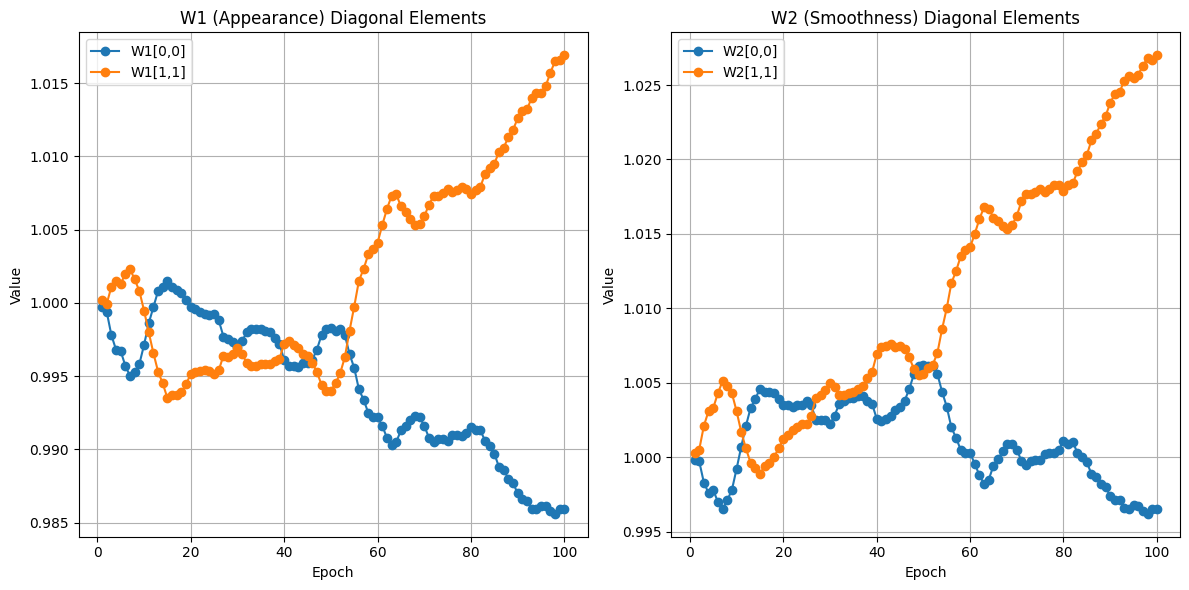

,1,6,11,16,21,26,31,36,41,46,51,56,61,66,71,76,81,86,91,96
w1_00,0.99972,0.9957,0.9986,1.00110,0.99960,0.9988,0.9974,0.9981,0.9957,0.9961,0.9981,0.9941,0.99160,0.99160,0.99080,0.9910,0.9913,0.98880,0.9866,0.9861
w1_11,1.00020,1.0020,0.9980,0.99370,0.99525,0.9954,0.9965,0.9958,0.9974,0.9959,0.9945,1.0015,1.00530,1.00620,1.00670,1.0076,1.0077,1.01030,1.0131,1.0148
w2_00,0.99980,0.9970,1.0007,1.00440,1.00350,1.0035,1.0028,1.0041,1.0024,1.0038,1.0061,1.0020,0.99955,0.99987,0.99976,1.0002,1.0009,0.99888,0.9971,0.9967
w2_11,1.00030,1.0043,1.0017,0.99938,1.00150,1.0028,1.0047,1.0046,1.0074,1.0073,1.0060,1.0117,1.01500,1.01590,1.01720,1.0178,1.0183,1.02130,1.0244,1.0257


In [52]:
tp = plot_weight_curves(lines)
tp.loc[:,range(1, 101, 5)]

In [35]:
import pickle

trainer_result = {
    '_results': trainer._results,
    'best_epoch': trainer.best_epoch,
    'best_loss': trainer.best_loss,
    'train_loss': trainer.train_loss,
    'loss': trainer.loss,
}

with open(f'{RESULT_DIR}/trainer_result.pickle', 'wb') as f:
    pickle.dump(trainer_result, f)

In [36]:
result_file_path = f'{RESULT_DIR}/trainer_result.pickle'

with open(result_file_path, 'rb') as file:
    trainer_result = pickle.load(file)

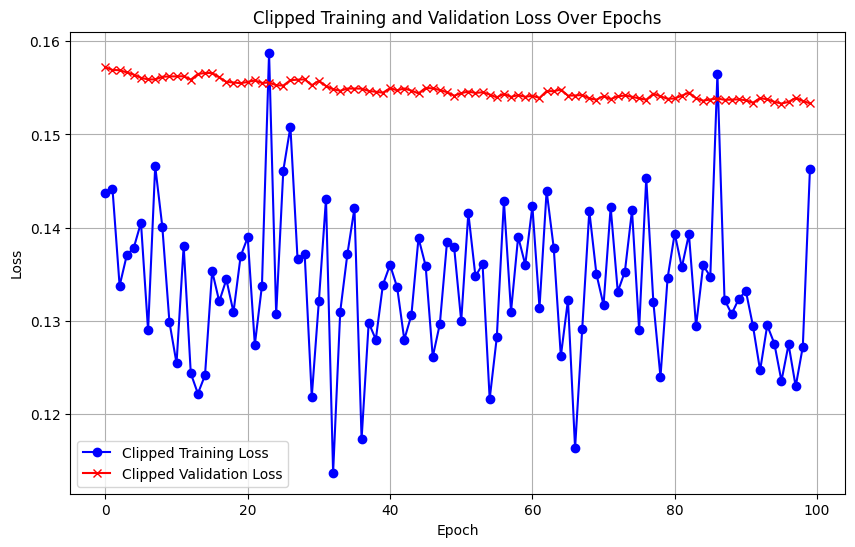

In [37]:
import matplotlib.pyplot as plt

train_losses = trainer_result['train_loss']
val_losses = trainer_result['loss']  # Assuming 'loss' contains the validation losses

max_loss = 1  # Set a threshold for maximum loss to visualize

clipped_train_losses = [min(loss, max_loss) for loss in train_losses]
clipped_val_losses = [min(loss, max_loss) for loss in val_losses]

plt.figure(figsize=(10, 6))
plt.plot(clipped_train_losses, label='Clipped Training Loss', color='blue', marker='o')
plt.plot(clipped_val_losses, label='Clipped Validation Loss', color='red', marker='x')
plt.title('Clipped Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## ⭐ Evaluate

In [38]:
import gc
gc.collect()
torch.cuda.empty_cache()

from torchvision.utils import save_image
from dataset import reconstruct_patched, collate_fn

def simple_micrograph_preprocessing(micrograph):
  micrograph_copy = micrograph.copy()
  micrograph_copy = (micrograph_copy-micrograph.mean()+2.5*micrograph.std())/5/micrograph.std()
  micrograph_copy[micrograph_copy<0]=0
  micrograph_copy[micrograph_copy>1]=1
  return micrograph_copy

!mkdir {RESULT_DIR}/Each_ckpt

### ⏭ Test score for all saved checkpoint.

In [39]:
# Check the last five best epochs
if not user:
    model = model_post
    checkpoint_paths = [path for path in os.listdir(RESULT_DIR) if '.pt' in path]
    for checkpoint_path in checkpoint_paths[-5:]:
        state_dict_path = f"{RESULT_DIR}/{checkpoint_path}"
        state_dict = torch.load(state_dict_path, map_location=torch.device(DEVICE))
        model.load_state_dict(state_dict, strict=False)
        model.eval()
        print("\nLoad model at: ", state_dict_path)
        #trainer = CryoEMTrainerWithScheduler(model, train_dataset, criterion, optimizer, device,
        #              num_classes=NUM_CLASSES,
        #              lr_scheduler=scheduler, patience=ES_PATIENCE)
        #result = trainer.evaluate(test_loader)
        model.to(DEVICE)
        model.eval()
        mini_batch_size = 9  # Number of patches to process at once
        with torch.no_grad():
            idx, (test_image, dnzd_test_image, _, grid, _) = next(enumerate(test_dataset))
            inputs = test_image.to(DEVICE)
            pairwise = dnzd_test_image.to(device) if (dnzd_test_image is not None) else None
            num_batches = (inputs.size(0) + mini_batch_size - 1) // mini_batch_size
            patched_outputs = []

            for batch_idx in range(num_batches):
                start_idx = batch_idx * mini_batch_size
                end_idx = min(start_idx + mini_batch_size, inputs.size(0))
                patch_input = inputs[start_idx:end_idx].to(DEVICE)
                patch_pairwise = pairwise[start_idx:end_idx].to(DEVICE) if (pairwise is not None) else None
                output = model(patch_input, patch_pairwise)['out']
                patched_outputs.append(output.cpu())  # Move to CPU to conserve GPU memory

                del patch_input
                torch.cuda.empty_cache()
            outputs = torch.cat(patched_outputs).to(DEVICE)  # Move to CPU to conserve GPU memory
            del patched_outputs
            torch.cuda.empty_cache()
            preds = outputs.argmax(dim=1).unsqueeze(1).cpu().detach()  # Now preds will have shape [81, 1, 512, 512]

            ## Plotting
            micrograph = np.load(f"{IMAGE_DIR}/val/{val_filenames[idx][:-4]}.npy")
            label_path = f"{LABEL_DIR}/{val_filenames[idx][:-4]}.png"


            micrograph_copy = simple_micrograph_preprocessing(micrograph)
            #crop_amount = 128  # Amount cropped from each side of the label image
            mic_width, mic_height = micrograph_copy.shape[1], micrograph_copy.shape[0]

            # Calculate starting and ending indices for cropping the micrograph
            #start_x = int((mic_width - 3840) / 2)
            #end_x = start_x + 3840
            #start_y = int((mic_height - 3840) / 2)
            #end_y = start_y + 3840

            # Crop the micrograph
            cropped_micrograph = micrograph_copy
            pred_image = reconstruct_patched(preds, grid).float()

            _,ax = plt.subplots(figsize=(12, 12))
            ax.imshow(cropped_micrograph, cmap='gray')
            ax.imshow(pred_image.squeeze(), cmap='inferno', alpha=0.4)
            plt.show()
            ##

            filename = f"{os.path.splitext(checkpoint_path)[0]}.png"
            pred_path = os.path.join(RESULT_DIR, "Each_ckpt", filename)
            save_image(pred_image, pred_path)

### ✅ Testing

In [40]:
# @markdown do testing
model = model_post
# dir_name = "unet_eb5_dice_CRF" # @param {type:"string"}
CHECKPOINT_PATH = RESULT_DIR

dir_path = CHECKPOINT_PATH
import glob
search_pattern = os.path.join(dir_path, '*.pt')
list_of_files = glob.glob(search_pattern)
latest_file = max(list_of_files, key=os.path.getmtime)
print(f"Directory searched: {dir_path}")
print("-" * 30)
print(f"The **last modified checkpoint** file is:\n{latest_file}")


state_dict_path = latest_file
state_dict = torch.load(state_dict_path, map_location=torch.device(DEVICE))
model.load_state_dict(state_dict, strict=False)
model.to(DEVICE)
model.eval()
print("Load model at: ", state_dict_path)

Directory searched: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF
------------------------------
The **last modified checkpoint** file is:
/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint96.pt
Load model at:  /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/WEIGHT_MULTIPLE_TEST/rst_2/10017/unet_eb5_dice_CRF/checkpoint96.pt


In [41]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [42]:
if not user:
    test_dir = os.path.join(IMAGE_DIR, 'test')
    test_filenames = np.loadtxt(f"{IMAGE_DIR}/test_filenames.txt", dtype=str)
    np.random.seed(24)
    selected_filenames = np.random.choice(test_filenames, size=6, replace=False)
    print(selected_filenames)
    test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, filenames=selected_filenames, crop_size=CROP_SIZE)
    test_loader = DataLoader(test_dataset, batch_size=None, shuffle=False, pin_memory=True)

In [43]:
evaluator = CryoEMEvaluator(
    model=model, device=DEVICE, metrics=['AP','iou'],
    num_classes=NUM_CLASSES)
print("ConvCRF validation result:")
result = evaluator.evaluate(loader=val_loader)
if not user:
    print("ConvCRF test result:")
    result = evaluator.evaluate(loader=test_loader)

ConvCRF validation result:
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
Iou by Class: [0.87539566 0.63825834]
Precision by Class: [0.9465272 0.7452563]
Recall by Class: [0.92094016 0.8163643 ]
Accuracy by Class: [0.8978529 0.8978529]
F1_score by Class: [0.9335584 0.7791913]


In [44]:
# @markdown ---
# @markdown time used
end_time = time.time()
print(f"End time recorded: {end_time}")

elapsed_time = end_time - start_time
elapsed_time = elapsed_time


hours = int(elapsed_time // 3600)
remaining_seconds = elapsed_time % 3600

minutes = int(remaining_seconds // 60)
seconds = round(remaining_seconds % 60, 3)

print(f"Time spend : {hours} h, {minutes} m, {seconds} s")


gpu_used = "L4" # @param ["CPU high", "T4", "T4 high", "L4"]
per_unit_cost_dict = {"L4" : 1.71, "T4 high" : 1.41, "T4" : 1.19, "CPU high" :  0.24}
per_unit_cost = per_unit_cost_dict[gpu_used]
print(f"unit price per hr {per_unit_cost}")

cost_units = per_unit_cost * elapsed_time / 3600

per_unit_US = 10.49 / 100

cost_price_US = cost_units * per_unit_US

print(f"unit cost : {round(cost_units, 4)}")
print(f"unit price US: {cost_price_US}")
print(f"unit price NTD: {cost_price_US * 30.76}")

End time recorded: 1767079362.5708375
Time spend : 1 h, 17 m, 44.976 s
unit price per hr 1.71
unit cost : 2.2159
unit price US: 0.23244408329201577
unit price NTD: 7.149980002062406
